# The AI Disconnect: Hype vs. Investment Across 12 Economies

**Rajarshi (Raj) Majumder**

Public interest in AI is not the same signal as capital committed to AI. This notebook maps the two against each other across 12 economies, then projects the gap forward five years.

## Every figure traces to a named public source

| Metric | Source | Vintage |
|---|---|---|
| GDP (current US$) | [World Bank API](https://data.worldbank.org/indicator/NY.GDP.MKTP.CD) — `NY.GDP.MKTP.CD` | 2024 |
| Population, total | [World Bank API](https://data.worldbank.org/indicator/SP.POP.TOTL) — `SP.POP.TOTL` | 2024 |
| AI public interest ("hype") | Google Trends — "ChatGPT" search interest by country | trailing 12mo |
| Private AI investment | [Stanford HAI AI Index 2025](https://hai.stanford.edu/assets/files/hai_ai-index-report-2025_chapter4_final.pdf) Fig 4.3.8/4.3.9 & [2026](https://hai.stanford.edu/assets/files/ai_index_report_2026_chapter_4_economy.pdf) Fig 4.2.8/4.2.12 | 2024, 2025 |
| AI Preparedness Index | IMF AIPI Dashboard, 174 economies | 2023 |

**What this measures, and what it does not.** Private AI investment is *capital committed* — not revenue, not market size. No public country-level index for AI revenue exists; this notebook does not claim one. The distinction matters: this shows where money is going, not where value has been captured.

**Country set: 12 ** Brazil and Spain appear in no investment table in either Stanford HAI report. The Netherlands has a 2024 single-year figure but never appears in either cumulative table. Rather than estimate them, they are dropped. Of the 12, **9** have a matched 2024/2025 pair and are carried into the forecast.

## Method

`StandardScaler` → `KMeans` groups countries by hype/investment behaviour rather than geography. The five-year outlook projects the **annual flow** and accumulates it onto the stock, with each country's real 2024→2025 growth decaying toward Stanford HAI's stated long-run trend (~29.2%/yr). The decay constant is ordered by IMF AI preparedness rather than hand-picked.

Built while working through the ML module of the IBM Data Science Professional Certificate.

## 1. Setup

In [7]:
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 8]

import requests

COUNTRIES_ISO3 = {
    'United States': 'USA', 'China': 'CHN', 'United Kingdom': 'GBR', 'Germany': 'DEU',
    'Japan': 'JPN', 'Singapore': 'SGP', 'United Arab Emirates': 'ARE', 'France': 'FRA',
    'India': 'IND', 'Canada': 'CAN', 'South Korea': 'KOR', 'Australia': 'AUS'
}
COUNTRIES_ISO2 = {
    'United States': 'US', 'China': 'CN', 'United Kingdom': 'GB', 'Germany': 'DE',
    'Japan': 'JP', 'Singapore': 'SG', 'United Arab Emirates': 'AE', 'France': 'FR',
    'India': 'IN', 'Canada': 'CA', 'South Korea': 'KR', 'Australia': 'AU'
}

## 2. World Bank — GDP and population

Live pull from the World Bank API, with a dated cited fallback so the notebook runs end to end on a restricted network.

In [9]:
# ---------------------------------------------------------------------------
# SECTION 1 -- World Bank: GDP and population, live pull with cited fallback
# ---------------------------------------------------------------------------
def fetch_worldbank_indicator(iso3, indicator, year=2024):
    url = f"https://api.worldbank.org/v2/country/{iso3}/indicator/{indicator}?format=json&date={year}"
    r = requests.get(url, timeout=10)
    r.raise_for_status()
    payload = r.json()[1][0]
    return payload['value'], payload['date']

WB_GDP_BILLION_USD_2024 = {
    'United States': 29184.9, 'China': 18273.4, 'United Kingdom': 3587.5, 'Germany': 4659.9,
    'Japan': 4026.2, 'Singapore': 530.7, 'United Arab Emirates': 536.9, 'France': 3174.1,
    'India': 3937.0, 'Canada': 2241.3, 'South Korea': 1869.9, 'Australia': 1790.3
}
WB_POPULATION_MILLIONS_2024 = {
    'United States': 340.1, 'China': 1410.7, 'United Kingdom': 68.3, 'Germany': 83.6,
    'Japan': 123.8, 'Singapore': 6.0, 'United Arab Emirates': 10.7, 'France': 68.2,
    'India': 1450.9, 'Canada': 40.8, 'South Korea': 51.7, 'Australia': 26.6
}

rows = []
for name, iso3 in COUNTRIES_ISO3.items():
    try:
        gdp_usd, gdp_year = fetch_worldbank_indicator(iso3, 'NY.GDP.MKTP.CD')
        pop, pop_year = fetch_worldbank_indicator(iso3, 'SP.POP.TOTL')
        gdp_billion, pop_millions = gdp_usd / 1e9, pop / 1e6
        source = f"World Bank live ({gdp_year})"
    except Exception:
        gdp_billion = WB_GDP_BILLION_USD_2024[name]
        pop_millions = WB_POPULATION_MILLIONS_2024[name]
        source = "World Bank snapshot (2024, cached)"
    rows.append({'Country': name, 'Country_GDP_Billion_USD': gdp_billion,
                  'Population_Millions': pop_millions, 'GDP_Source': source})
    
df = pd.DataFrame(rows)
df.head()

,Country,Country_GDP_Billion_USD,Population_Millions,GDP_Source
0,United States,29298.013000,340.003797,World Bank live (2024)
1,China,18273.400000,1410.700000,"World Bank snapshot (2024, cached)"
2,United Kingdom,3695.539514,69.281000,World Bank live (2024)
3,Germany,4685.592578,83.516593,World Bank live (2024)
4,Japan,4190.008188,123.975371,World Bank live (2024)


## 3. Google Trends — AI public interest

Search interest is *relative within each country*, not a raw count, so a large population does not mechanically inflate the score.

In [13]:
# ---------------------------------------------------------------------------
# SECTION 2 -- Google Trends: "ChatGPT" interest, live pull with cited fallback
# ---------------------------------------------------------------------------
GOOGLE_TRENDS_CHATGPT_SNAPSHOT = {
    'United States': 11, 'China': 41, 'United Kingdom': 10, 'India': 30,
    'Canada': 17, 'France': 13, 'South Korea': 7, 'Japan': 4, 'Australia': 16,
    'Germany': 12, 'Singapore': 28, 'United Arab Emirates': 37
}
trends_source = "Google Trends snapshot (cached)"
try:
    from pytrends.request import TrendReq
    pytrends = TrendReq(hl='en-US', tz=360, retries=3, backoff_factor=0.5)
    pytrends.build_payload(["ChatGPT"], cat=0, timeframe='today 12-m', geo='')
    trends = pytrends.interest_by_region(resolution='COUNTRY', inc_low_vol=True, inc_geo_code=True).reset_index()
    trends = trends.rename(columns={'geoCode': 'ISO2', 'ChatGPT': 'Hype_Search_Interest'})
    df['ISO2'] = df['Country'].map(COUNTRIES_ISO2)
    df = df.merge(trends[['ISO2', 'Hype_Search_Interest']], on='ISO2', how='left')
    trends_source = "Google Trends live (trailing 12 months)"
except Exception:
    df['Hype_Search_Interest'] = df['Country'].map(GOOGLE_TRENDS_CHATGPT_SNAPSHOT)
df['Hype_Search_Interest'] = df['Hype_Search_Interest'].fillna(df['Country'].map(GOOGLE_TRENDS_CHATGPT_SNAPSHOT))
df.head()

,Country,Country_GDP_Billion_USD,Population_Millions,GDP_Source,ISO2,Hype_Search_Interest
0,United States,29298.013000,340.003797,World Bank live (2024),US,12
1,China,18273.400000,1410.700000,"World Bank snapshot (2024, cached)",CN,46
2,United Kingdom,3695.539514,69.281000,World Bank live (2024),GB,11
3,Germany,4685.592578,83.516593,World Bank live (2024),DE,13
4,Japan,4190.008188,123.975371,World Bank live (2024),JP,4


## 4. Stanford HAI — private AI investment

Read directly from the primary chapter PDFs. The two vintages cross-validate: for every country, (cumulative 2013–2025 − cumulative 2013–2024) matches the separately reported 2025 single-year figure to within rounding.

In [17]:
# ---------------------------------------------------------------------------
# SECTION 3 -- Stanford HAI: private AI investment, read directly from the
# primary chapter PDFs (see module docstring for exact figure references).
# ---------------------------------------------------------------------------
# Cumulative 2013-2025 (2026 report, Figure 4.2.12) -- primary stock metric
INVESTMENT_CUMULATIVE_2013_2025 = {
    'United States': 757.27, 'China': 131.83, 'United Kingdom': 34.07, 'Canada': 19.59,
    'Germany': 17.16, 'France': 15.57, 'India': 15.39, 'South Korea': 10.75,
    'Singapore': 9.09, 'Japan': 7.00, 'Australia': 6.50, 'United Arab Emirates': 4.24
}
# 2024 single-year (2025 report, Figure 4.3.8)
INVESTMENT_2024 = {
    'United States': 109.08, 'China': 9.29, 'United Kingdom': 4.52, 'Germany': 1.97,
    'France': 2.62, 'India': 1.16, 'United Arab Emirates': 1.77, 'South Korea': 1.33,
    'Canada': 2.89, 'Japan': 0.93
    # Singapore, Australia: not in the 2025 report's top-15 2024 list -- no explicit figure
}
# 2025 single-year (2026 report, Figure 4.2.8)
INVESTMENT_2025 = {
    'United States': 285.88, 'China': 12.41, 'United Kingdom': 5.90, 'France': 4.36,
    'Canada': 4.28, 'India': 4.09, 'Germany': 3.89, 'Australia': 2.52,
    'Singapore': 1.82, 'South Korea': 1.78, 'Japan': 1.11
    # UAE: not in the 2026 report's top-15 2025 list -- no explicit figure
}

df['Investment_Cumulative_Billion_USD'] = df['Country'].map(INVESTMENT_CUMULATIVE_2013_2025)
df['Investment_2024_Billion_USD'] = df['Country'].map(INVESTMENT_2024)
df['Investment_2025_Billion_USD'] = df['Country'].map(INVESTMENT_2025)
df['Investment_Intensity_Pct_GDP'] = (df['Investment_Cumulative_Billion_USD'] / df['Country_GDP_Billion_USD']) * 100

print(f"GDP / population source: {df['GDP_Source'].iloc[0]}")
print(f"Hype source: {trends_source}")
print("Investment source: Stanford HAI AI Index 2025 & 2026, Economy chapter (primary PDF)")
print(df[['Country', 'Population_Millions', 'Country_GDP_Billion_USD', 'Hype_Search_Interest',
          'Investment_Cumulative_Billion_USD', 'Investment_Intensity_Pct_GDP']].round(3).to_string(index=False))


GDP / population source: World Bank live (2024)
Hype source: Google Trends live (trailing 12 months)
Investment source: Stanford HAI AI Index 2025 & 2026, Economy chapter (primary PDF)
             Country  Population_Millions  Country_GDP_Billion_USD  Hype_Search_Interest  Investment_Cumulative_Billion_USD  Investment_Intensity_Pct_GDP
       United States              340.004                29298.013                    12                             757.27                         2.585
               China             1410.700                18273.400                    46                             131.83                         0.721
      United Kingdom               69.281                 3695.540                    11                              34.07                         0.922
             Germany               83.517                 4685.593                    13                              17.16                         0.366
               Japan              123.975    

## 5. Feature scaling and clustering

In [21]:
# ---------------------------------------------------------------------------
# SECTION 4 -- Scaler + clustering
#Sort these countries into 3 groups. Try 10 different starting arrangements and keep the best one. And make sure this is exactly repeatable, not random each time I run it."
# ---------------------------------------------------------------------------
features = ['Hype_Search_Interest', 'Investment_Intensity_Pct_GDP']
X_scaled = StandardScaler().fit_transform(df[features])
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)
print("\nCluster membership:")
for c in sorted(df['Cluster'].unique()):
    print(f"  Cluster {c}: {df[df.Cluster == c]['Country'].tolist()}")

#US outshine all in private investments till date with a very low Hype score


Cluster membership:
  Cluster 0: ['United Kingdom', 'Germany', 'Japan', 'France', 'Canada', 'South Korea', 'Australia']
  Cluster 1: ['China', 'Singapore', 'United Arab Emirates', 'India']
  Cluster 2: ['United States']


In [25]:
df_for_appendix = df.copy()  # protects the pipeline dataframe from later reassignment
df.head()

,Country,Country_GDP_Billion_USD,Population_Millions,GDP_Source,ISO2,Hype_Search_Interest,Investment_Cumulative_Billion_USD,Investment_2024_Billion_USD,Investment_2025_Billion_USD,Investment_Intensity_Pct_GDP,Cluster
0,United States,29298.013000,340.003797,World Bank live (2024),US,12,757.27,109.08,285.88,2.584715,2
1,China,18273.400000,1410.700000,"World Bank snapshot (2024, cached)",CN,46,131.83,9.29,12.41,0.721431,1
2,United Kingdom,3695.539514,69.281000,World Bank live (2024),GB,11,34.07,4.52,5.90,0.921922,0
3,Germany,4685.592578,83.516593,World Bank live (2024),DE,13,17.16,1.97,3.89,0.366229,0
4,Japan,4190.008188,123.975371,World Bank live (2024),JP,4,7.00,0.93,1.11,0.167064,0


## 6. The snapshot — where hype sits against Investments/Capital

Chart 1 plots hype against investment intensity. Chart 2 adds population scale, with bubble size carrying investment intensity.

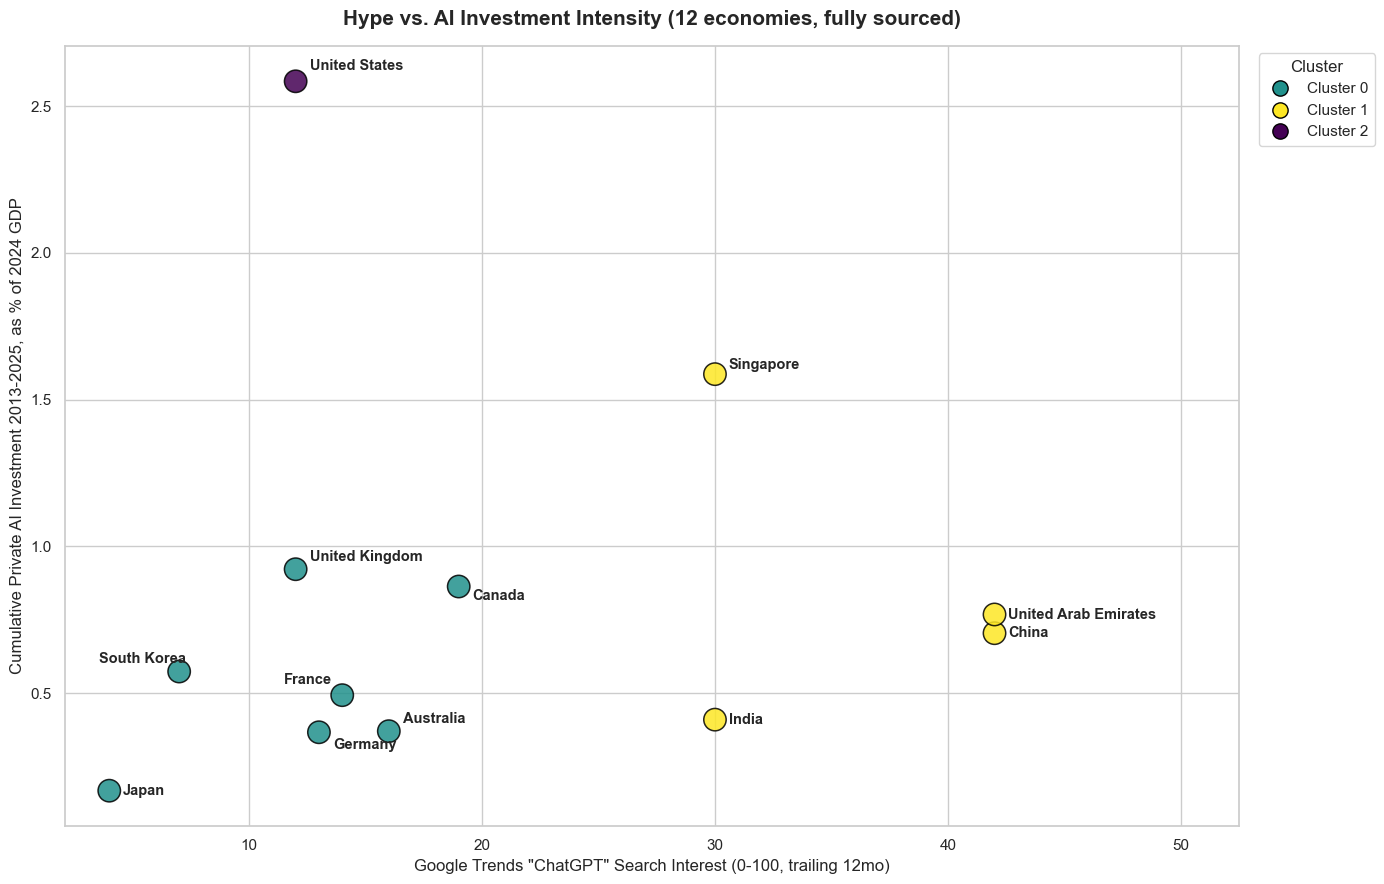

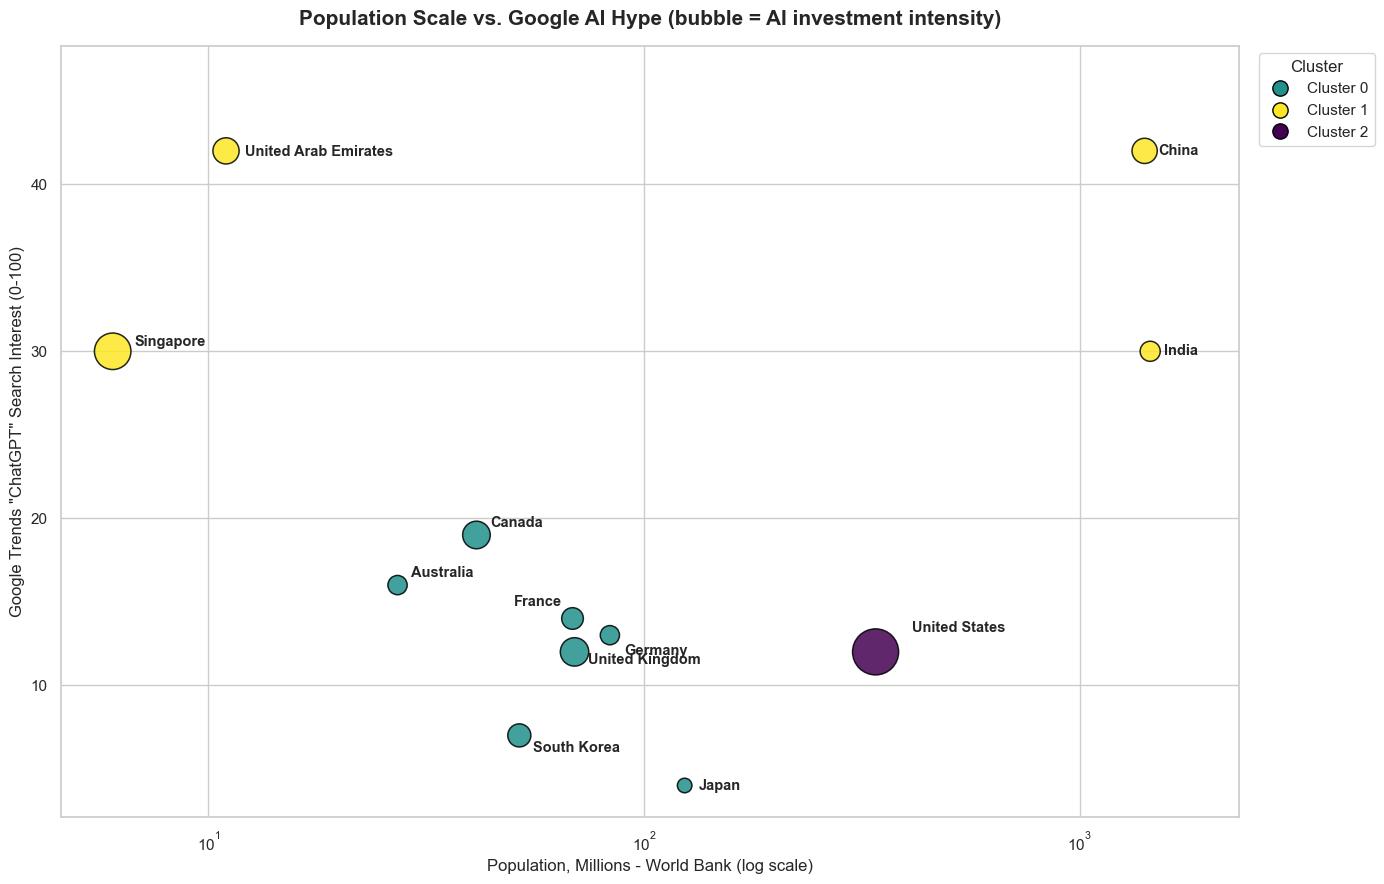

In [28]:
palette = {0: '#21918c', 1: '#fde725', 2: '#440154'}

# ---------------------------------------------------------------------------
# CHART 1 -- Hype vs investment intensity, 12 countries
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 9))
ax.scatter(df['Hype_Search_Interest'], df['Investment_Intensity_Pct_GDP'],
           s=260, c=df['Cluster'].map(palette), edgecolor='black', linewidth=1.1, alpha=0.85, zorder=3)
offsets1 = {
    'United States': (10, 8), 'China': (10, -3), 'India': (10, -3), 'United Kingdom': (10, 6),
    'Canada': (10, -10), 'France': (-42, 8), 'South Korea': (-58, 6), 'Japan': (10, -3),
    'Australia': (10, 6), 'Germany': (10, -12), 'Singapore': (10, 4), 'United Arab Emirates': (10, -3),
}
for _, r in df.iterrows():
    dx, dy = offsets1.get(r['Country'], (10, -3))
    ax.annotate(r['Country'], xy=(r['Hype_Search_Interest'], r['Investment_Intensity_Pct_GDP']),
                xytext=(dx, dy), textcoords='offset points', fontsize=10.5, fontweight='semibold', zorder=4)
ax.set_title('Hype vs. AI Investment Intensity (12 economies, fully sourced)', fontsize=15, weight='bold', pad=15)
ax.set_xlabel('Google Trends "ChatGPT" Search Interest (0-100, trailing 12mo)', fontsize=12)
ax.set_ylabel('Cumulative Private AI Investment 2013-2025, as % of 2024 GDP', fontsize=12)
ax.set_xlim(right=df['Hype_Search_Interest'].max() * 1.25)
legend_elems = [Line2D([0], [0], marker='o', linestyle='', markerfacecolor=palette[c],
                       markeredgecolor='black', markersize=11, label=f'Cluster {c}')
                for c in sorted(df['Cluster'].unique())]
ax.legend(handles=legend_elems, title='Cluster', loc='upper left', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# CHART 2 -- Population vs hype, bubble = investment intensity, 12 countries
# ---------------------------------------------------------------------------
size_min, size_max = 110, 1100
inv = df['Investment_Intensity_Pct_GDP']
sizes = size_min + (inv - inv.min()) / (inv.max() - inv.min()) * (size_max - size_min)

fig, ax = plt.subplots(figsize=(14, 9))
ax.set_xscale('log')
ax.scatter(df['Population_Millions'], df['Hype_Search_Interest'], s=sizes,
           c=df['Cluster'].map(palette), edgecolor='black', linewidth=1.1, alpha=0.85, zorder=3)
offsets2 = {
    'United States': (26, 14), 'China': (10, -3), 'India': (10, -3), 'United Kingdom': (10, -9),
    'Canada': (10, 6), 'France': (-42, 9), 'South Korea': (10, -12), 'Japan': (10, -3),
    'Australia': (10, 6), 'Germany': (10, -14), 'Singapore': (16, 4), 'United Arab Emirates': (14, -4),
}
for _, r in df.iterrows():
    dx, dy = offsets2.get(r['Country'], (10, -3))
    ax.annotate(r['Country'], xy=(r['Population_Millions'], r['Hype_Search_Interest']),
                xytext=(dx, dy), textcoords='offset points', fontsize=10.5, fontweight='semibold', zorder=4)
ax.set_title('Population Scale vs. Google AI Hype (bubble = AI investment intensity)', fontsize=15, weight='bold', pad=15)
ax.set_xlabel('Population, Millions - World Bank (log scale)', fontsize=12)
ax.set_ylabel('Google Trends "ChatGPT" Search Interest (0-100)', fontsize=12)
ax.set_ylim(top=ax.get_ylim()[1] * 1.1)
ax.set_xlim(right=df['Population_Millions'].max() * 1.6)
ax.legend(handles=legend_elems, title='Cluster', loc='upper left', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()
plt.close()

## 7. Real momentum, 2024 → 2025

Two panels on purpose. Growth rate alone rewards small bases: India tripling off \$1.16B tops the growth chart while adding less absolute capital than China, which looks slow at +34%. Sorting by capital added puts scale first.

       Country  Investment_2024_Billion_USD  Investment_2025_Billion_USD  Absolute_Change_Billion_USD  YoY_Growth_Pct
 United States                       109.08                       285.88                       176.80          162.08
         China                         9.29                        12.41                         3.12           33.58
         India                         1.16                         4.09                         2.93          252.59
       Germany                         1.97                         3.89                         1.92           97.46
        France                         2.62                         4.36                         1.74           66.41
        Canada                         2.89                         4.28                         1.39           48.10
United Kingdom                         4.52                         5.90                         1.38           30.53
   South Korea                         1.33             

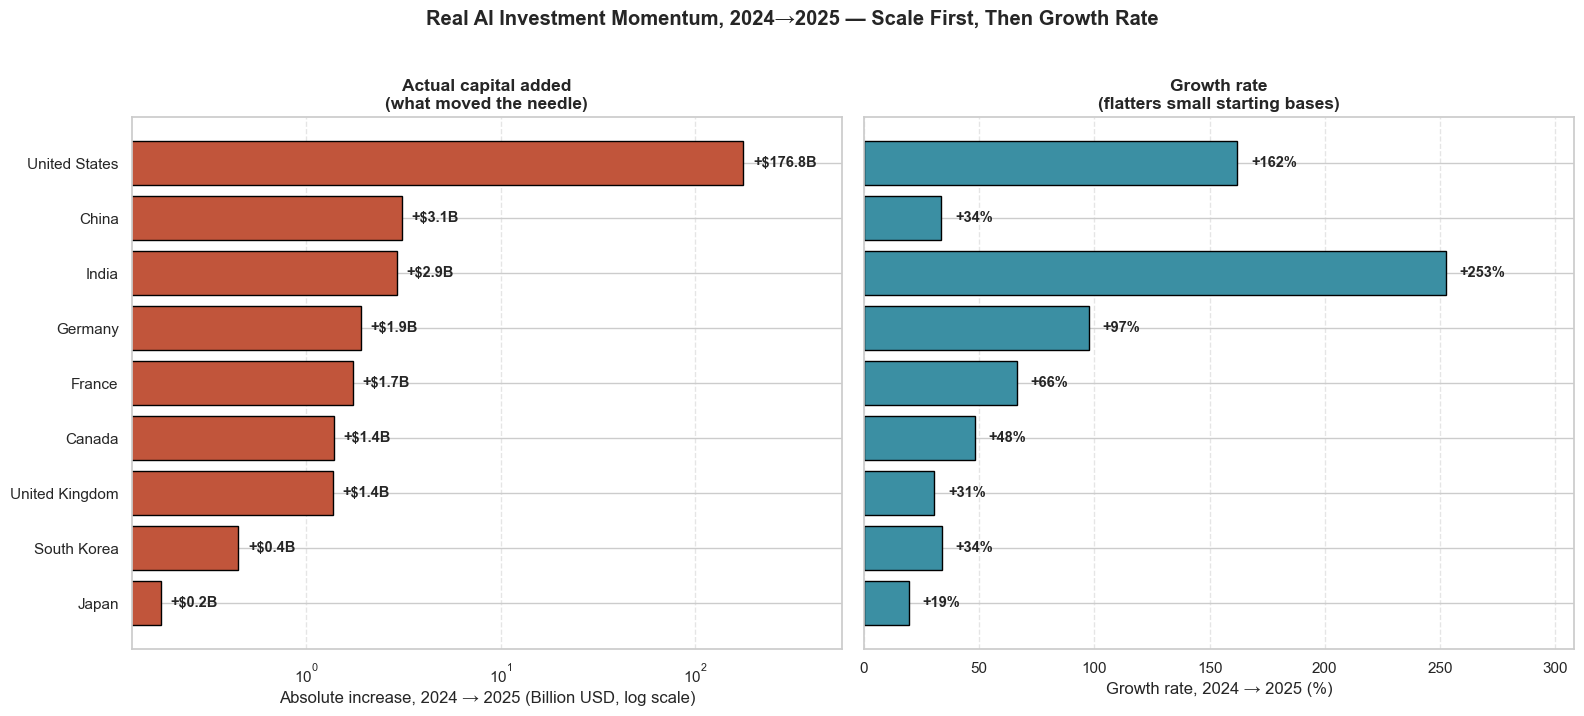

In [31]:
# ---------------------------------------------------------------------------
# Real 2024->2025 momentum, shown TWO ways on purpose.
#
# Sorted by ACTUAL CAPITAL ADDED (left panel), so scale leads the read and
# the growth-rate panel is seen in that context. Percentage growth alone
# rewards small bases: India tripling off $1.16B tops the growth chart while
# adding less absolute capital than China, which looks slow at +34%.
#
# Source: Stanford HAI AI Index 2025 (Fig 4.3.8) and 2026 (Fig 4.2.8),
# Economy chapter, primary PDFs.
# ---------------------------------------------------------------------------
m = df.dropna(subset=['Investment_2024_Billion_USD', 'Investment_2025_Billion_USD']).copy()
m['YoY_Growth_Pct'] = (m['Investment_2025_Billion_USD'] / m['Investment_2024_Billion_USD'] - 1) * 100
m['Absolute_Change_Billion_USD'] = m['Investment_2025_Billion_USD'] - m['Investment_2024_Billion_USD']
m = m.sort_values('Absolute_Change_Billion_USD', ascending=False)

print(m[['Country', 'Investment_2024_Billion_USD', 'Investment_2025_Billion_USD',
         'Absolute_Change_Billion_USD', 'YoY_Growth_Pct']].round(2).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# LEFT: actual capital added (the scale story)
bars1 = axes[0].barh(m['Country'], m['Absolute_Change_Billion_USD'], color='#c1553b', edgecolor='black')
for bar, val in zip(bars1, m['Absolute_Change_Billion_USD']):
    axes[0].text(val * 1.12, bar.get_y() + bar.get_height() / 2, f"+${val:,.1f}B",
                 va='center', fontsize=10.5, fontweight='semibold')
axes[0].set_xscale('log')
axes[0].set_xlabel('Absolute increase, 2024 \u2192 2025 (Billion USD, log scale)', fontsize=12)
axes[0].set_title('Actual capital added\n(what moved the needle)', fontsize=12.5, weight='bold')
axes[0].set_xlim(right=m['Absolute_Change_Billion_USD'].max() * 3.2)
axes[0].invert_yaxis()
axes[0].grid(True, axis='x', linestyle='--', alpha=0.5)

# RIGHT: growth rate (same country order)
bars2 = axes[1].barh(m['Country'], m['YoY_Growth_Pct'], color='#3b8fa3', edgecolor='black')
for bar, val in zip(bars2, m['YoY_Growth_Pct']):
    axes[1].text(val + 6, bar.get_y() + bar.get_height() / 2, f"+{val:.0f}%",
                 va='center', fontsize=10.5, fontweight='semibold')
axes[1].set_xlabel('Growth rate, 2024 \u2192 2025 (%)', fontsize=12)
axes[1].set_title('Growth rate\n(flatters small starting bases)', fontsize=12.5, weight='bold')
axes[1].set_xlim(right=m['YoY_Growth_Pct'].max() * 1.22)
axes[1].grid(True, axis='x', linestyle='--', alpha=0.5)

fig.suptitle('Real AI Investment Momentum, 2024\u21922025 \u2014 Scale First, Then Growth Rate',
             fontsize=14.5, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Five-year outlook

**Growth rates belong on the flow, not the stock.** A cumulative total can only rise by the new capital added each year — applying a 29.2% growth rate to China's \$131.8B stock would imply \$38.5B of new investment in 2026, 3.1× its actual 2025 flow. So the flow is projected and then accumulated.

Each country's real 2024→2025 growth decays exponentially toward the long-run trend. Only the 9 countries with a genuine matched pair are projected.

       Country  Year  Annual_Flow_Billion_USD  Cumulative_Billion_USD
 United States  2030                   1900.8                  6522.5
         China  2030                     45.8                   277.8
         India  2030                     38.5                   128.6
United Kingdom  2030                     21.4                   102.4
       Germany  2030                     19.6                    78.0
        France  2030                     19.0                    75.2
        Canada  2030                     17.0                    73.5
   South Korea  2030                      6.6                    31.7
         Japan  2030                      3.8                    19.2


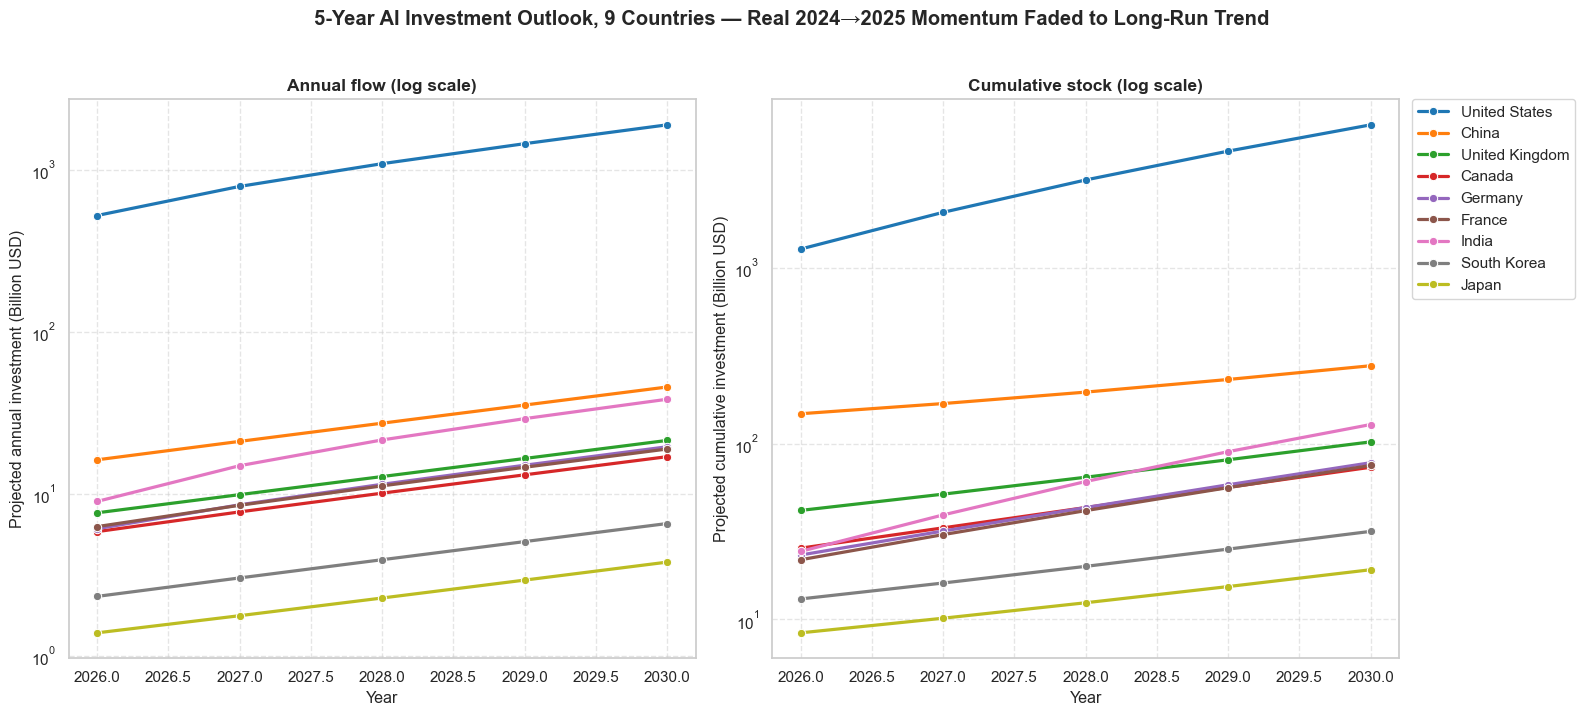

In [34]:
# =============================================================================
# 5-Year AI Investment Outlook
#
# Method: project the ANNUAL FLOW forward, then accumulate it onto the
# 2013-2025 cumulative stock.
#
# Why not grow the stock directly: a cumulative total can only increase by the
# new capital added each year. Applying a 29.2% growth rate to China's $131.8B
# stock implies $38.5B of new investment in 2026 -- 3.1x its actual 2025 flow
# of $12.4B. Growth rates belong on the flow, not the stock.
#
# Each country's own real 2024->2025 growth rate is faded toward Stanford HAI's
# stated long-run trend ("more than thirteenfold since 2014" -> ~29.2%/yr)
# via exponential decay. Nine countries have a real matched 2024/2025 pair;
# only those are projected.
#
# Sources: Stanford HAI AI Index 2025 (Figs 4.3.8, 4.3.9) and 2026
# (Figs 4.2.8, 4.2.12), Economy chapter, primary PDFs.
# =============================================================================

# Cumulative private AI investment 2013-2025 (2026 report, Fig 4.2.12)
CUMULATIVE_2025 = {
    'United States': 757.27, 'China': 131.83, 'United Kingdom': 34.07, 'Canada': 19.59,
    'Germany': 17.16, 'France': 15.57, 'India': 15.39, 'South Korea': 10.75, 'Japan': 7.00
}
LONG_RUN_CAGR = 13 ** (1 / 10) - 1   # Stanford HAI: "13x since 2014"
K_DECAY = 0.9
years = list(range(2026, 2031))

# Real 2024 and 2025 annual flows, from `m` (built in Cell 2)
flows = m.set_index('Country')[['Investment_2024_Billion_USD', 'Investment_2025_Billion_USD']]

records = []
for country, stock in CUMULATIVE_2025.items():
    f24 = flows.loc[country, 'Investment_2024_Billion_USD']
    f25 = flows.loc[country, 'Investment_2025_Billion_USD']
    excess0 = (f25 / f24 - 1) - LONG_RUN_CAGR      # real momentum above trend
    flow, cum = f25, stock
    for t, yr in enumerate(years, start=1):
        g_t = LONG_RUN_CAGR + excess0 * np.exp(-K_DECAY * t)
        flow = flow * (1 + g_t)                     # grow the FLOW
        cum = cum + flow                            # accumulate onto the STOCK
        records.append({'Country': country, 'Year': yr,
                        'Annual_Flow_Billion_USD': flow,
                        'Cumulative_Billion_USD': cum})

df_forecast = pd.DataFrame(records)
print(df_forecast[df_forecast.Year == 2030].sort_values('Cumulative_Billion_USD', ascending=False)
      .round(1).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, col, label in zip(
        axes,
        ['Annual_Flow_Billion_USD', 'Cumulative_Billion_USD'],
        ['Projected annual investment (Billion USD)', 'Projected cumulative investment (Billion USD)']):
    sns.lineplot(data=df_forecast, x='Year', y=col, hue='Country',
                 palette='tab10', linewidth=2.3, marker='o', ax=ax, legend=(col == 'Cumulative_Billion_USD'))
    ax.set_yscale('log')
    ax.set_ylabel(label, fontsize=11.5)
    ax.set_xlabel('Year', fontsize=11.5)
    ax.grid(True, linestyle='--', alpha=0.5)
axes[0].set_title('Annual flow (log scale)', fontsize=12.5, weight='bold')
axes[1].set_title('Cumulative stock (log scale)', fontsize=12.5, weight='bold')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

fig.suptitle('5-Year AI Investment Outlook, 9 Countries \u2014 Real 2024\u21922025 Momentum Faded to Long-Run Trend',
             fontsize=14.5, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. Grounding the decay constant in AI preparedness

A single hand-picked `k` for every country is the weakest assumption in the model. Instead, `k` is **ordered** by the IMF AI Preparedness Index: higher readiness → sustains above-trend growth longer → slower decay.

**Scope note.** AIPI grounds the *ordering and relative spacing* of `k`. The bounds (0.9, 2.5) remain a modelling choice — the IMF says India is less prepared than the US, not that its excess growth halves in 3.4 months. `k=0.9` is the baseline for the most-prepared economy, so preparedness only ever *speeds decay up*, never slows it below that floor.

This is **parameterisation, not validation** — with one growth observation there is nothing yet to test against. It becomes testable when 2026 flow data lands.

Long-run trend: 29.2%   |   k range 0.9-2.5

       Country  AIPI    k  half_life_yr  start_growth_%  excess_pp
 United States  0.77 0.90          0.77             162        133
       Germany  0.75 1.01          0.68              97         68
         Japan  0.73 1.13          0.61              19        -10
United Kingdom  0.73 1.13          0.61              31          1
   South Korea  0.73 1.13          0.61              34          5
        Canada  0.71 1.24          0.56              48         19
        France  0.70 1.30          0.53              66         37
         China  0.64 1.64          0.42              34          4
         India  0.49 2.50          0.28             253        223

2030 annual flow -- uniform k=0.9 vs AIPI-parameterized k:
       Country  k_AIPI  uniform_k0.9  AIPI_k  change_%
         India    2.50          38.5    17.1       -56
        France    1.30          19.0    17.5        -8
       Germany    1.01          19.6    18.5        -5
     

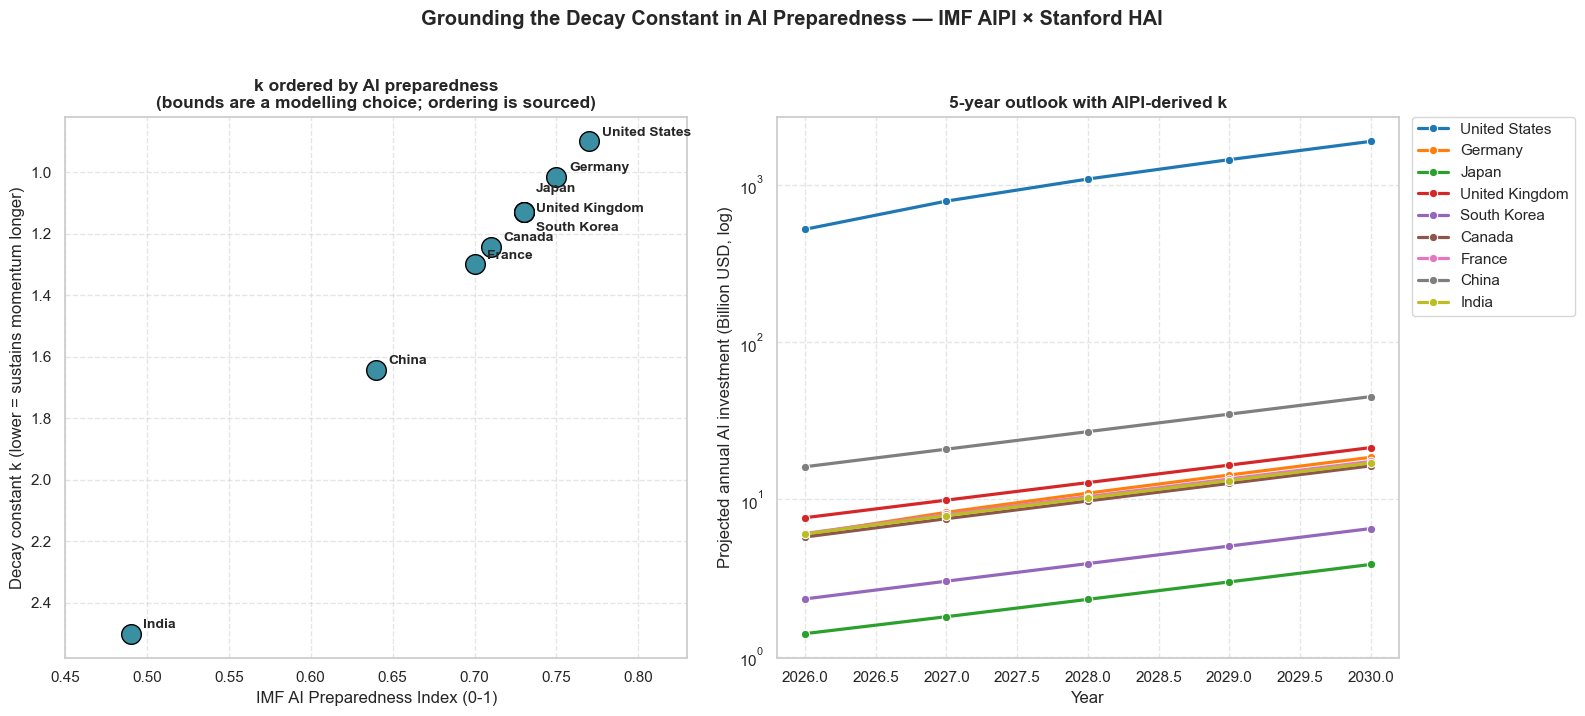

In [37]:
"""
AIPI-parameterized decay constant k
------------------------------------
Instead of a single hand-picked k for every country, k is derived from the
IMF AI Preparedness Index (AIPI): a country with higher AI readiness
(infrastructure, human capital, innovation, regulation) is assumed able to
SUSTAIN above-trend investment growth longer -> slower decay -> lower k.
Lower readiness -> faster reversion to trend -> higher k.

    k_i = k_max - (AIPI_i - AIPI_min)/(AIPI_max - AIPI_min) * (k_max - k_min)

HONEST SCOPE NOTE: AIPI grounds the ORDERING and relative spacing of k across
countries. The absolute bounds (k_min, k_max) remain a modeling choice -- AIPI
says India is less prepared than the US, not that its excess growth halves in
X months. State this in the write-up; don't imply the IMF set the bounds.

AIPI source: IMF AI Preparedness Index (2023, 174 economies), as published in
the IMF AIPI Dashboard. Values below transcribed from the full published table.
"""

AIPI = {
    'United States': 0.77, 'Germany': 0.75, 'Japan': 0.73, 'United Kingdom': 0.73,
    'South Korea': 0.73, 'Canada': 0.71, 'France': 0.70, 'China': 0.64, 'India': 0.49,
}
FLOW_2024 = {'United States':109.08,'China':9.29,'India':1.16,'Germany':1.97,'France':2.62,
             'Canada':2.89,'United Kingdom':4.52,'South Korea':1.33,'Japan':0.93}
FLOW_2025 = {'United States':285.88,'China':12.41,'India':4.09,'Germany':3.89,'France':4.36,
             'Canada':4.28,'United Kingdom':5.90,'South Korea':1.78,'Japan':1.11}
CUM_2025  = {'United States':757.27,'China':131.83,'United Kingdom':34.07,'Canada':19.59,
             'Germany':17.16,'France':15.57,'India':15.39,'South Korea':10.75,'Japan':7.00}

LONG_RUN_CAGR = 13 ** (1/10) - 1
K_MIN, K_MAX = 0.9, 2.5   # 0.9 = baseline for the most AI-prepared economy; AIPI only speeds decay up
a_lo, a_hi = min(AIPI.values()), max(AIPI.values())
k_of = {c: K_MAX - (v - a_lo)/(a_hi - a_lo) * (K_MAX - K_MIN) for c, v in AIPI.items()}

print(f"Long-run trend: {LONG_RUN_CAGR*100:.1f}%   |   k range {K_MIN}-{K_MAX}\n")
rows = []
for c in AIPI:
    g25 = FLOW_2025[c]/FLOW_2024[c] - 1
    rows.append({'Country': c, 'AIPI': AIPI[c], 'k': round(k_of[c], 2),
                 'half_life_yr': round(np.log(2)/k_of[c], 2),
                 'start_growth_%': round(g25*100), 'excess_pp': round((g25-LONG_RUN_CAGR)*100)})
print(pd.DataFrame(rows).sort_values('AIPI', ascending=False).to_string(index=False))

years = list(range(2026, 2031))
records = []
for c in AIPI:
    excess0 = (FLOW_2025[c]/FLOW_2024[c] - 1) - LONG_RUN_CAGR
    flow, cum = FLOW_2025[c], CUM_2025[c]
    for t, yr in enumerate(years, start=1):
        g_t = LONG_RUN_CAGR + excess0 * np.exp(-k_of[c] * t)
        flow *= (1 + g_t)
        cum += flow
        records.append({'Country': c, 'Year': yr, 'Annual_Flow_B': flow, 'Cumulative_B': cum})
fc = pd.DataFrame(records)

print("\n2030 annual flow -- uniform k=0.9 vs AIPI-parameterized k:")
cmp = []
for c in AIPI:
    excess0 = (FLOW_2025[c]/FLOW_2024[c] - 1) - LONG_RUN_CAGR
    v_u = FLOW_2025[c]
    for t in range(1, 6):
        v_u *= (1 + LONG_RUN_CAGR + excess0*np.exp(-0.9*t))
    v_a = fc[(fc.Country==c) & (fc.Year==2030)]['Annual_Flow_B'].iloc[0]
    cmp.append({'Country': c, 'k_AIPI': round(k_of[c],2), 'uniform_k0.9': round(v_u,1),
                'AIPI_k': round(v_a,1), 'change_%': round((v_a/v_u-1)*100)})
print(pd.DataFrame(cmp).sort_values('change_%').to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
ax = axes[0]
sc = ax.scatter([AIPI[c] for c in AIPI], [k_of[c] for c in AIPI],
                s=200, c='#3b8fa3', edgecolor='black', zorder=3)
label_dy = {'Japan': 14, 'United Kingdom': 0, 'South Korea': -14}
for c in AIPI:
    ax.annotate(c, (AIPI[c], k_of[c]), xytext=(9, label_dy.get(c, 4)),
                textcoords='offset points', fontsize=10, fontweight='semibold')
ax.set_xlabel('IMF AI Preparedness Index (0-1)', fontsize=12)
ax.set_ylabel('Decay constant k (lower = sustains momentum longer)', fontsize=12)
ax.set_title('k ordered by AI preparedness\n(bounds are a modelling choice; ordering is sourced)',
             fontsize=12.5, weight='bold')
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_xlim(a_lo-0.04, a_hi+0.06)
ax.invert_yaxis()   # k descends upward: higher preparedness sits higher on the chart

ax = axes[1]
sns.lineplot(data=fc, x='Year', y='Annual_Flow_B', hue='Country', palette='tab10',
             linewidth=2.3, marker='o', ax=ax)
ax.set_yscale('log')
ax.set_ylabel('Projected annual AI investment (Billion USD, log)', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.set_title('5-year outlook with AIPI-derived k', fontsize=12.5, weight='bold')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
ax.grid(True, linestyle='--', alpha=0.5)

fig.suptitle('Grounding the Decay Constant in AI Preparedness \u2014 IMF AIPI \u00d7 Stanford HAI',
             fontsize=14.5, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 10. What if momentum persists?

The decay assumption matters enormously for one country and almost not at all for another — and that asymmetry is the finding.

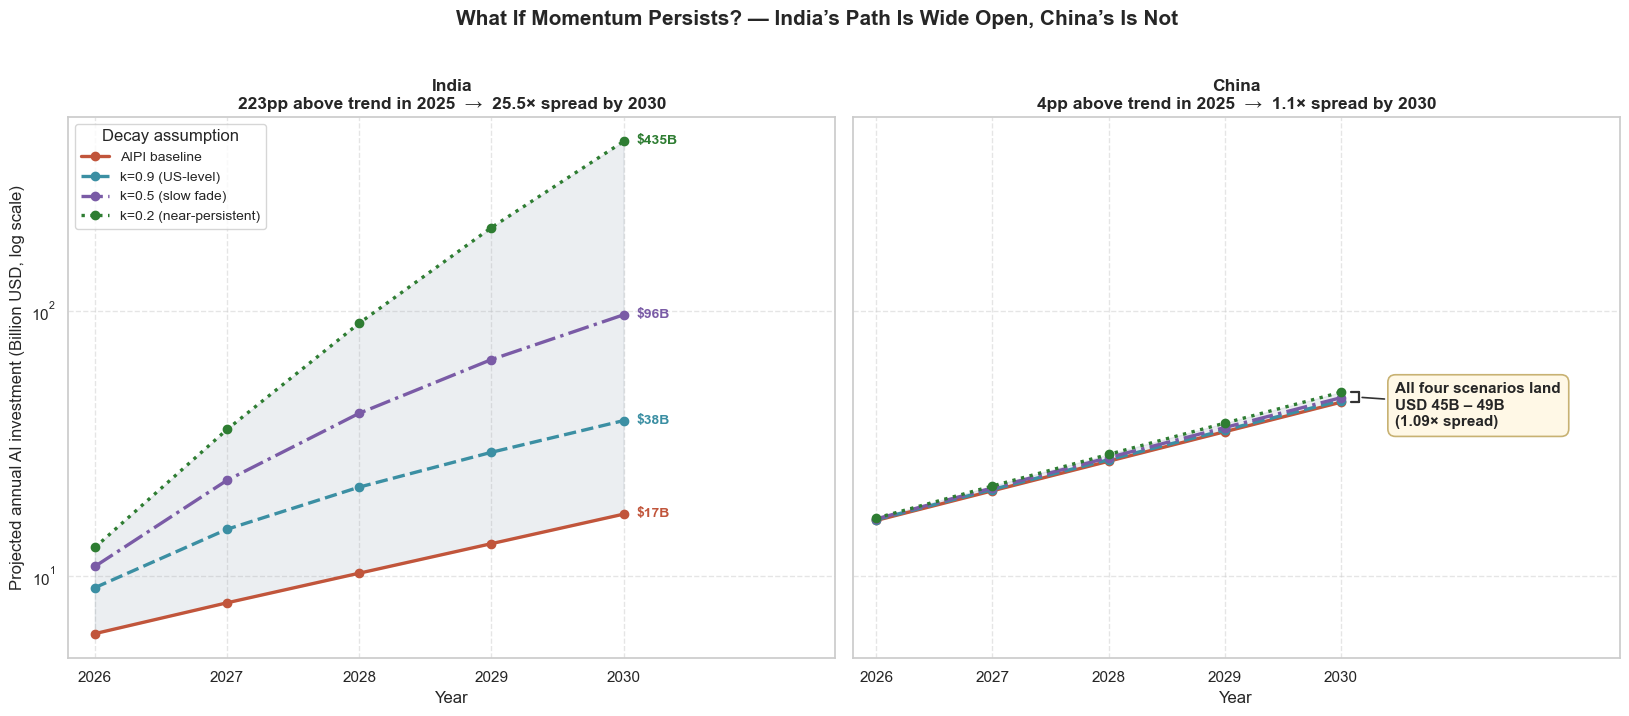

Country                Scenario    k  Flow_2030_B
  India           AIPI baseline 2.50         17.1
  India        k=0.9 (US-level) 0.90         38.5
  India       k=0.5 (slow fade) 0.50         96.5
  India k=0.2 (near-persistent) 0.20        435.2
  China           AIPI baseline 1.64         45.1
  China        k=0.9 (US-level) 0.90         45.8
  China       k=0.5 (slow fade) 0.50         46.9
  China k=0.2 (near-persistent) 0.20         49.2


In [40]:
"""
Scenario fan: what if India or China sustains momentum longer?
---------------------------------------------------------------
k controls how fast a country's 2024->2025 excess growth fades toward the
long-run trend (~29.2%/yr, per Stanford HAI's "13x since 2014").

The point is the ASYMMETRY:
  - India: 2025 growth 252.6% = 223.3pp above trend -> k dominates (25.5x spread)
  - China: 2025 growth  33.6% =   4.3pp above trend -> k is ~irrelevant (1.1x)

Because China's scenarios converge, its endpoint labels would overlap into an
unreadable stack. That panel uses a single bracketed range callout instead --
the convergence IS the finding, so it's stated once, clearly.

Sources: Stanford HAI AI Index 2025 (Fig 4.3.8) & 2026 (Fig 4.2.8);
IMF AI Preparedness Index 2023 for the baseline k.
"""

LONG_RUN_CAGR = 13 ** (1/10) - 1
F24 = {'China': 9.29,  'India': 1.16}
F25 = {'China': 12.41, 'India': 4.09}
BASE_K = {'China': 1.64, 'India': 2.50}
SCENARIOS = [
    ('AIPI baseline',           None, '#c1553b', '-'),
    ('k=0.9 (US-level)',        0.90, '#3b8fa3', '--'),
    ('k=0.5 (slow fade)',       0.50, '#7a5ba6', '-.'),
    ('k=0.2 (near-persistent)', 0.20, '#2e7d32', ':'),
]
years = list(range(2026, 2031))

def project(country, k):
    excess0 = (F25[country] / F24[country] - 1) - LONG_RUN_CAGR
    flow, out = F25[country], []
    for t in range(1, len(years) + 1):
        flow *= (1 + LONG_RUN_CAGR + excess0 * np.exp(-k * t))
        out.append(flow)
    return out

fig, axes = plt.subplots(1, 2, figsize=(16.5, 7), sharey=True)

for ax, country in zip(axes, ['India', 'China']):
    series = {}
    for label, k, colour, ls in SCENARIOS:
        kk = BASE_K[country] if k is None else k
        series[label] = project(country, kk)

    # envelope band between fastest- and slowest-decay scenarios
    lo_env = [min(v[i] for v in series.values()) for i in range(len(years))]
    hi_env = [max(v[i] for v in series.values()) for i in range(len(years))]
    ax.fill_between(years, lo_env, hi_env, color='#8899aa', alpha=0.16, zorder=1)

    for label, k, colour, ls in SCENARIOS:
        ax.plot(years, series[label], marker='o', linewidth=2.4,
                color=colour, linestyle=ls, label=label, zorder=3)

    finals = [series[lbl][-1] for lbl, _, _, _ in SCENARIOS]
    spread = max(finals) / min(finals)

    if spread < 1.5:
        # converged -> one bracketed callout instead of four overlapping labels
        lo, hi = min(finals), max(finals)
        xb = years[-1] + 0.16
        for seg in ([[xb, xb], [lo, hi]], [[xb - 0.07, xb], [lo, lo]], [[xb - 0.07, xb], [hi, hi]]):
            ax.plot(seg[0], seg[1], color='#333333', lw=1.6, zorder=4)
        ax.annotate("All four scenarios land\n"
                    f"USD {lo:,.0f}B \u2013 {hi:,.0f}B\n"
                    f"({spread:.2f}\u00d7 spread)",
                    xy=(xb, np.sqrt(lo * hi)), xytext=(26, -6), textcoords='offset points',
                    fontsize=11, fontweight='semibold', va='center',
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='#fff8e6',
                              edgecolor='#c8b273', linewidth=1.2),
                    arrowprops=dict(arrowstyle='-', color='#333333', lw=1.2))
        ax.set_xlim(2025.8, 2032.4)
    else:
        for (label, k, colour, ls), val in zip(SCENARIOS, finals):
            ax.annotate(f"${val:,.0f}B", (years[-1], val), xytext=(9, 0),
                        textcoords='offset points', fontsize=10,
                        fontweight='semibold', color=colour, va='center')
        ax.set_xlim(2025.8, 2031.6)

    excess = (F25[country] / F24[country] - 1 - LONG_RUN_CAGR) * 100
    ax.set_title(f"{country}\n{excess:.0f}pp above trend in 2025  \u2192  {spread:.1f}\u00d7 spread by 2030",
                 fontsize=12.5, weight='bold')
    ax.set_yscale('log')
    ax.set_xlabel('Year', fontsize=12)
    ax.set_xticks(years)
    ax.grid(True, linestyle='--', alpha=0.5)

axes[0].set_ylabel('Projected annual AI investment (Billion USD, log scale)', fontsize=12)
axes[0].legend(title='Decay assumption', loc='upper left', fontsize=10)

fig.suptitle('What If Momentum Persists? \u2014 India\u2019s Path Is Wide Open, China\u2019s Is Not',
             fontsize=15, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

rows = []
for country in ['India', 'China']:
    for label, k, _, _ in SCENARIOS:
        kk = BASE_K[country] if k is None else k
        rows.append({'Country': country, 'Scenario': label, 'k': kk,
                     'Flow_2030_B': round(project(country, kk)[-1], 1)})
out = pd.DataFrame(rows)
print(out.to_string(index=False))

## 11. Full investment history, with hype side by side

Every year on record for the 9-country panel — private investment, year-over-year growth, and the Google Trends hype score used throughout this project, in one table. 2022 is included for the US and China (the AI Index 2023 report's primary text); other countries have no earlier country-level figure published.

*One fix from the original version of this chart: the subtitle previously said "2020–2021 not yet pulled." 2021 figures for the US, China, and UK were pulled separately (see the real-trend line chart) — they just aren't in this 9-country matched panel, since the other six countries have no 2021 figure to pair them with.*

/var/folders/tz/h2wd92c91qsf45pg59dtjcgh0000gn/T/ipykernel_53622/2733720387.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


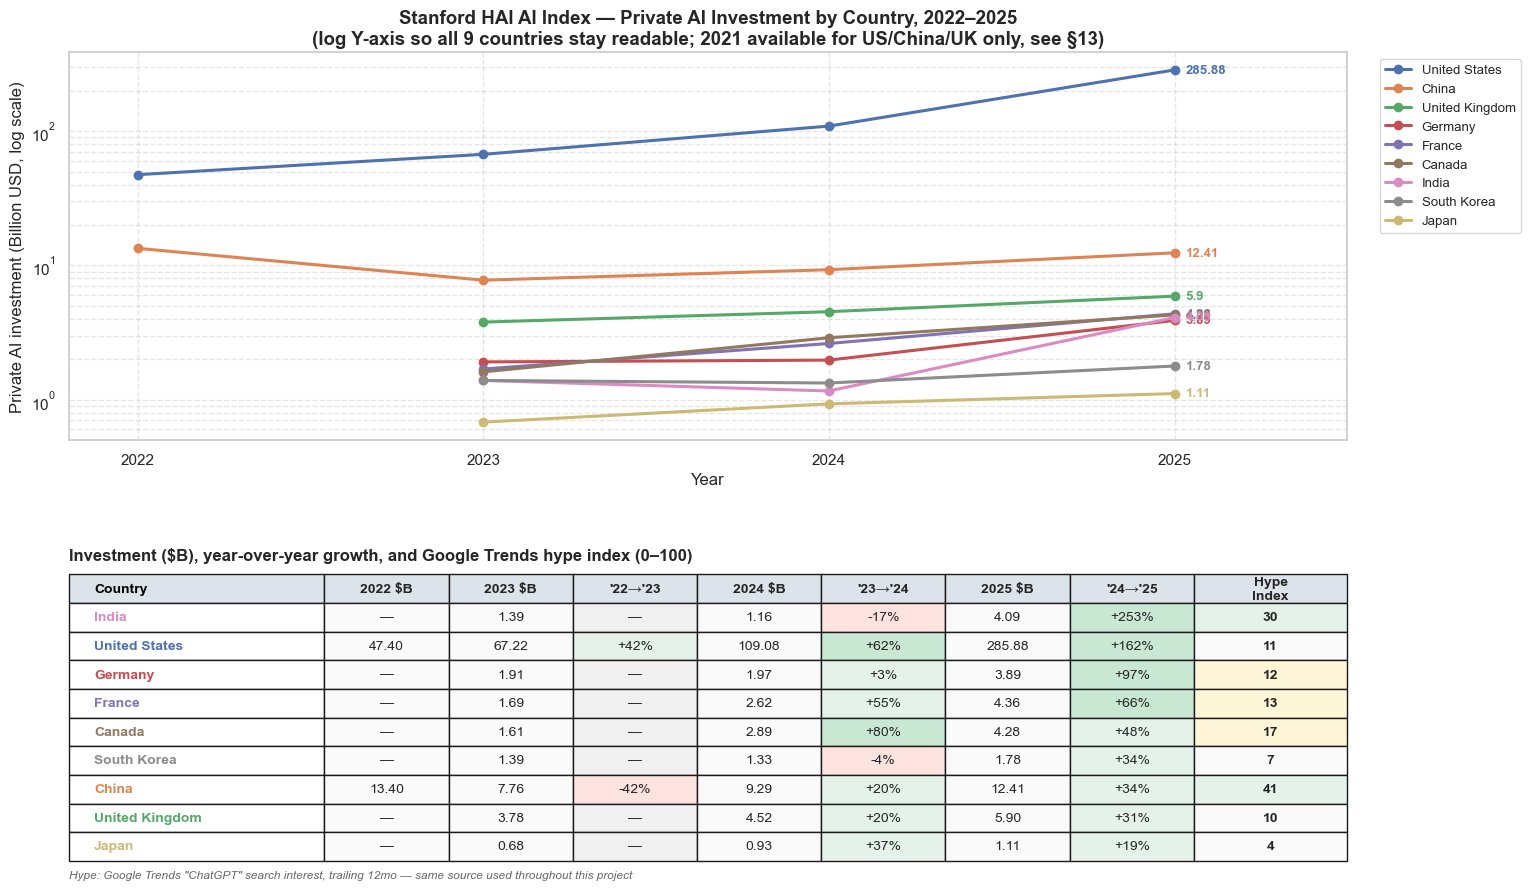

In [43]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
sns.set_theme(style="whitegrid")

DATA = {
    'United States': {2022:47.4, 2023:67.22, 2024:109.08, 2025:285.88},
    'China':         {2022:13.4, 2023:7.76,  2024:9.29,   2025:12.41},
    'United Kingdom':{              2023:3.78, 2024:4.52, 2025:5.90},
    'Germany':       {              2023:1.91, 2024:1.97, 2025:3.89},
    'France':        {              2023:1.69, 2024:2.62, 2025:4.36},
    'Canada':        {              2023:1.61, 2024:2.89, 2025:4.28},
    'India':         {              2023:1.39, 2024:1.16, 2025:4.09},
    'South Korea':   {              2023:1.39, 2024:1.33, 2025:1.78},
    'Japan':         {              2023:0.68, 2024:0.93, 2025:1.11},
}
# Google Trends "ChatGPT" search interest, 0-100, trailing 12mo -- same source used
# throughout this project (Hype_Search_Interest in the main dataset)
HYPE = {'United States':11,'China':41,'United Kingdom':10,'Germany':12,'France':13,
        'Canada':17,'India':30,'South Korea':7,'Japan':4}
YEARS = [2022, 2023, 2024, 2025]

fig = plt.figure(figsize=(16.5, 10.5))
gs = gridspec.GridSpec(2, 1, height_ratios=[2.3, 1.7], hspace=0.4)
ax = fig.add_subplot(gs[0])
ax_t = fig.add_subplot(gs[1])
ax_t.axis('off')

colors = {}
for country, series in DATA.items():
    yrs = sorted(series)
    vals = [series[y] for y in yrs]
    line, = ax.plot(yrs, vals, marker='o', linewidth=2.2, label=country)
    colors[country] = line.get_color()
    ax.annotate(f"{vals[-1]:g}", (yrs[-1], vals[-1]), xytext=(8, 0),
                textcoords='offset points', va='center', fontsize=9.5,
                fontweight='semibold', color=line.get_color())

ax.set_yscale('log')
ax.set_xlim(2021.8, 2025.5)
ax.set_xticks(YEARS)
ax.set_ylabel('Private AI investment (Billion USD, log scale)', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.set_title('Stanford HAI AI Index \u2014 Private AI Investment by Country, 2022\u20132025\n'
             '(log Y-axis so all 9 countries stay readable; 2021 available for US/China/UK only, see \u00a713)',
             fontsize=13.5, weight='bold')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9.5)
ax.grid(True, which='both', ls='--', alpha=.5)

def yoy(series):
    out = []
    for a, b in zip(YEARS, YEARS[1:]):
        out.append((series[b] / series[a] - 1) * 100 if (a in series and b in series) else None)
    return out

rows = []
for country, series in DATA.items():
    g = yoy(series)
    rows.append((country, series, g))
rows.sort(key=lambda r: (r[2][-1] is None, -(r[2][-1] or -999)))

col_labels = ['Country', '2022 $B', '2023 $B', "'22\u2192'23", '2024 $B', "'23\u2192'24",
              '2025 $B', "'24\u2192'25", 'Hype\nIndex']
cell_text, cell_colors = [], []
for country, series, g in rows:
    def d(y): return f"{series[y]:.2f}" if y in series else "\u2014"
    def gr(v): return "\u2014" if v is None else f"{v:+.0f}%"
    cell_text.append([country, d(2022), d(2023), gr(g[0]), d(2024), gr(g[1]),
                       d(2025), gr(g[2]), str(HYPE[country])])
    def gcol(v):
        if v is None: return '#f0f0f0'
        return '#fde3df' if v < 0 else ('#e4f2ea' if v < 60 else '#c9e8d4')
    hcol = '#e4f2ea' if HYPE[country] >= 25 else ('#fff6d8' if HYPE[country] >= 12 else '#fafafa')
    cell_colors.append(['white', '#fafafa', '#fafafa', gcol(g[0]), '#fafafa', gcol(g[1]),
                         '#fafafa', gcol(g[2]), hcol])

tbl = ax_t.table(cellText=cell_text, colLabels=col_labels, cellColours=cell_colors,
                  cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
n_cols = len(col_labels)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#dde3ea')
    if c == 0:
        cell.set_text_props(weight='bold', color=colors.get(cell.get_text().get_text(), 'black'))
        cell._text.set_ha('left')
    if c == n_cols - 1 and r > 0:
        cell.set_text_props(weight='bold')
    cell.set_width(0.20 if c == 0 else (0.68 / (n_cols - 2)) if c < n_cols - 1 else 0.12)
ax_t.set_title('Investment ($B), year-over-year growth, and Google Trends hype index (0\u2013100)',
               fontsize=12, weight='bold', pad=10, loc='left')
ax_t.text(0, -0.06, 'Hype: Google Trends "ChatGPT" search interest, trailing 12mo \u2014 same source used throughout this project',
          transform=ax_t.transAxes, fontsize=8.5, style='italic', color='#666')

plt.tight_layout()
plt.savefig('hai_investment_2020_2025.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Private capital + other commitments (government pledges, infra capex)

A second table, not a replacement for the first. "Other" is capital Stanford HAI's private-investment methodology doesn't count — government pledges and infrastructure commitments like the US Stargate initiative or France's national AI plan. These are one-off announcements on their own timelines, not an annual series, so they're **not** comparable to the private-investment figures without a caveat: multi-year totals are divided into equal annual placeholders, and only the UK's durations are confirmed from primary reporting — everywhere else, a 5-year window is an assumption, flagged as such in the table notes below.

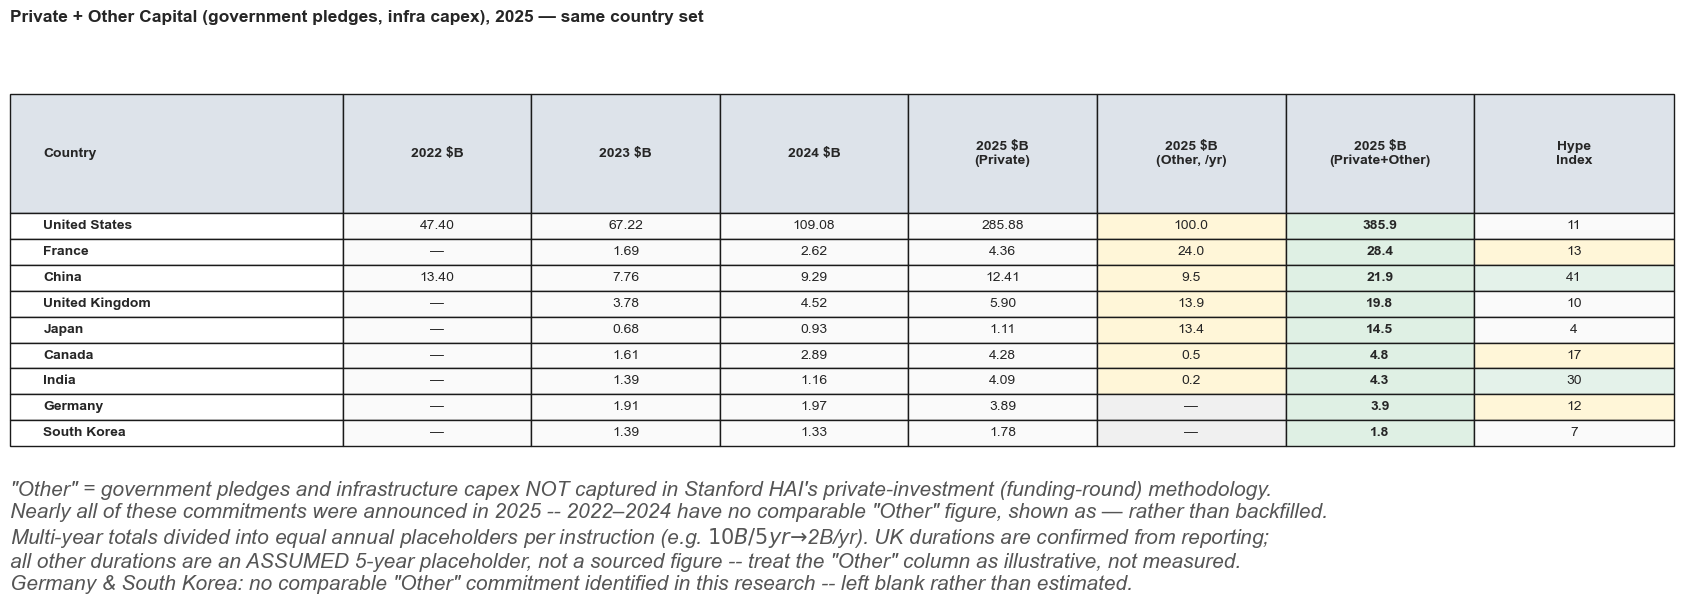

United States Stargate infra initiative (OpenAI/SoftBank/Oracle) — ASSUMED 5yr, $500B/5
France National AI investment plan (multi-year pledge) — ASSUMED 5yr, $120B/5
China State semiconductor fund (adjacent, not AI-specific) — ASSUMED 5yr, $47.5B/5
United Kingdom Microsoft, 2025-2028 ($30B/4yr) + Google, 2025-2026 ($6.8B/2yr) + Nvidia/Nscale/CoreWeave, duration assumed ($15B/5yr)
Japan Public AI/semiconductor infra support — ASSUMED 5yr, $67B/5
Canada Government AI pledge — ASSUMED 5yr, $2.4B/5
India IndiaAI Mission (appropriated budget) — ASSUMED 5yr, $1.25B/5
Germany None
South Korea None


In [46]:
"""
Second table: Private + Other (government pledges, infra capex) capital.
Does NOT touch the chart -- appends a new table image below the existing one.

"Other" figures are one-off pledges/commitments, each on a different clock --
not an annual series like Stanford HAI's private-investment data. Per
instruction: multi-year totals are split into equal annual placeholders
(e.g. $10B over 5yr -> $2B/yr). Where a duration was confirmed in our
research (UK hyperscaler deals), that real duration is used. Everywhere
else, a 5-year placeholder is assumed and flagged explicitly -- this is a
modeling assumption, not a sourced duration.

Because virtually all of these commitments were announced in 2025, only the
2025 column gets an "Other" value; 2022-2024 are dashes, honestly, rather
than backfilled.
"""
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import Markdown

sns.set_theme(style="whitegrid")

PRIVATE = {
    'United States': {2022:47.4, 2023:67.22, 2024:109.08, 2025:285.88},
    'China':         {2022:13.4, 2023:7.76,  2024:9.29,   2025:12.41},
    'United Kingdom':{              2023:3.78, 2024:4.52, 2025:5.90},
    'Germany':       {              2023:1.91, 2024:1.97, 2025:3.89},
    'France':        {              2023:1.69, 2024:2.62, 2025:4.36},
    'Canada':        {              2023:1.61, 2024:2.89, 2025:4.28},
    'India':         {              2023:1.39, 2024:1.16, 2025:4.09},
    'South Korea':   {              2023:1.39, 2024:1.33, 2025:1.78},
    'Japan':         {              2023:0.68, 2024:0.93, 2025:1.11},
}
HYPE = {'United States':11,'China':41,'United Kingdom':10,'Germany':12,'France':13,
        'Canada':17,'India':30,'South Korea':7,'Japan':4}

# "Other" = government pledges + infra capex, NOT in the private/Quid table.
# (total_$B, duration_years, duration_confirmed?, description)
OTHER_RAW = {
    'United States': (500.0, 5, False, 'Stargate infra initiative (OpenAI/SoftBank/Oracle)'),
    'China':         (47.5,  5, False, 'State semiconductor fund (adjacent, not AI-specific)'),
    'United Kingdom':(None,  None, None, None),  # built from 3 pieces below, real durations
    'France':        (120.0, 5, False, 'National AI investment plan (multi-year pledge)'),
    'Japan':         (67.0,  5, False, 'Public AI/semiconductor infra support'),
    'Canada':        (2.4,   5, False, 'Government AI pledge'),
    'India':         (1.25,  5, False, 'IndiaAI Mission (appropriated budget)'),
    'Germany':       (None, None, None, None),
    'South Korea':   (None, None, None, None),
}
# UK: three separate pieces, real confirmed durations from primary reporting
UK_PIECES = [(30.0, 4, 'Microsoft, 2025-2028'), (6.8, 2, 'Google, 2025-2026'),
             (15.0, 5, 'Nvidia/Nscale/CoreWeave, duration assumed')]

def other_2025(entry):
    total, yrs, confirmed, desc = entry
    if total is None:
        return None, None
    return total / yrs, f"{desc} \u2014 {'confirmed' if confirmed else 'ASSUMED'} {yrs}yr, ${total:g}B/{yrs}"

other_annual = {}
other_note = {}
for country, entry in OTHER_RAW.items():
    if country == 'United Kingdom':
        continue
    val, note = other_2025(entry)
    other_annual[country] = val
    other_note[country] = note
uk_annual = sum(p[0] / p[1] for p in UK_PIECES)
other_annual['United Kingdom'] = uk_annual
other_note['United Kingdom'] = " + ".join(f"{d} (${t:g}B/{y}yr)" for t, y, d in UK_PIECES)

YEARS = [2022, 2023, 2024, 2025]

def yoy(series):
    out = []
    for a, b in zip(YEARS, YEARS[1:]):
        out.append((series[b] / series[a] - 1) * 100 if (a in series and b in series) else None)
    return out

rows = []
for country, series in PRIVATE.items():
    priv_2025 = series[2025]
    oth = other_annual.get(country)
    total_2025 = priv_2025 + oth if oth else priv_2025
    rows.append((country, series, oth, total_2025))
rows.sort(key=lambda r: -r[3])

fig = plt.figure(figsize=(17, 6.2))
ax_t = fig.add_subplot(111)
ax_t.axis('off')

col_labels = ['Country', '2022 $B', '2023 $B', '2024 $B', '2025 $B\n(Private)',
              '2025 $B\n(Other, /yr)', '2025 $B\n(Private+Other)', 'Hype\nIndex']
cell_text, cell_colors = [], []
colors = {}
for country, series, oth, total in rows:
    def d(y): return f"{series[y]:.2f}" if y in series else "\u2014"
    oth_s = "\u2014" if oth is None else f"{oth:.1f}"
    cell_text.append([country, d(2022), d(2023), d(2024), f"{series[2025]:.2f}",
                       oth_s, f"{total:.1f}", str(HYPE[country])])
    row_colors = ['white', '#fafafa', '#fafafa', '#fafafa', '#fafafa',
                  ('#fff6d8' if oth is not None else '#f0f0f0'), '#dff0e4',
                  '#e4f2ea' if HYPE[country] >= 25 else ('#fff6d8' if HYPE[country] >= 12 else '#fafafa')]
    cell_colors.append(row_colors)

tbl = ax_t.table(cellText=cell_text, colLabels=col_labels, cellColours=cell_colors,
                  cellLoc='center', loc='center', bbox=[0, 0.08, 1, 0.8])
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
n_cols = len(col_labels)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#dde3ea')
        cell.set_height(0.16)
    if c == 0:
        cell._text.set_ha('left')
        cell.set_text_props(weight='bold')
    if c == 6 and r > 0:
        cell.set_text_props(weight='bold')
    cell.set_width(0.20 if c == 0 else (0.68 / (n_cols - 2)) if c < n_cols - 1 else 0.12)

ax_t.set_title('Private + Other Capital (government pledges, infra capex), 2025 \u2014 same country set',
               fontsize=12.5, weight='bold', pad=14, loc='left')
notes = (
    '"Other" = government pledges and infrastructure capex NOT captured in Stanford HAI\'s private-investment (funding-round) methodology.\n'
    'Nearly all of these commitments were announced in 2025 -- 2022\u20132024 have no comparable "Other" figure, shown as \u2014 rather than backfilled.\n'
    'Multi-year totals divided into equal annual placeholders per instruction (e.g. $10B/5yr \u2192 $2B/yr). UK durations are confirmed from reporting;\n'
    'all other durations are an ASSUMED 5-year placeholder, not a sourced figure -- treat the "Other" column as illustrative, not measured.\n'
    'Germany & South Korea: no comparable "Other" commitment identified in this research -- left blank rather than estimated.'
)
ax_t.text(0, 0.0, notes, transform=ax_t.transAxes, fontsize=15, style='italic', color='#555', va='top')

plt.tight_layout()
plt.savefig('table2_private_plus_other.png', dpi=150, bbox_inches='tight')
plt.show()
for c in rows:
    print(c[0], other_note.get(c[0]))


## 13. Does hype converge with investment — now, or in 5 years?

The question this whole project is trying to answer, put to a real fitted trend instead of a hand-picked decay constant. Log-linear regression on each country's actual annual points (3 for most, 4 for the US and China, which includes the 2022 pre-boom year), extrapolated to 2030.

**Caveat on China's fit:** R²=0.001. Its 2022–2025 points sit on a dip-then-recover curve, not a line — the regression forces a flat trend through that shape and reports "no trend," which should be read as "the model doesn't fit," not as a finding.

Fitted trend per country (log-linear regression on real points):
       Country  n_points     years  fitted_CAGR_%    R2  2025_actual  proj_2030
 United States         4 2022-2025           79.9 0.945       285.88     4547.3
        Canada         3 2023-2025           63.0 0.987         4.28       50.9
         India         3 2023-2025           71.5 0.627         4.09       47.8
        France         3 2023-2025           60.6 0.998         4.36       46.1
       Germany         3 2023-2025           42.7 0.783         3.89       20.7
United Kingdom         3 2023-2025           24.9 0.987         5.90       17.7
         China         4 2022-2025           -0.5 0.001        12.41       10.1
         Japan         3 2023-2025           27.8 0.975         1.11        3.9
   South Korea         3 2023-2025           13.2 0.620         1.78        3.1

DOES HYPE MATCH INVESTMENT?
  Spearman rank correlation, hype vs 2025 investment:      rho=+0.45  (p=0.22)
  Spearman rank correlation

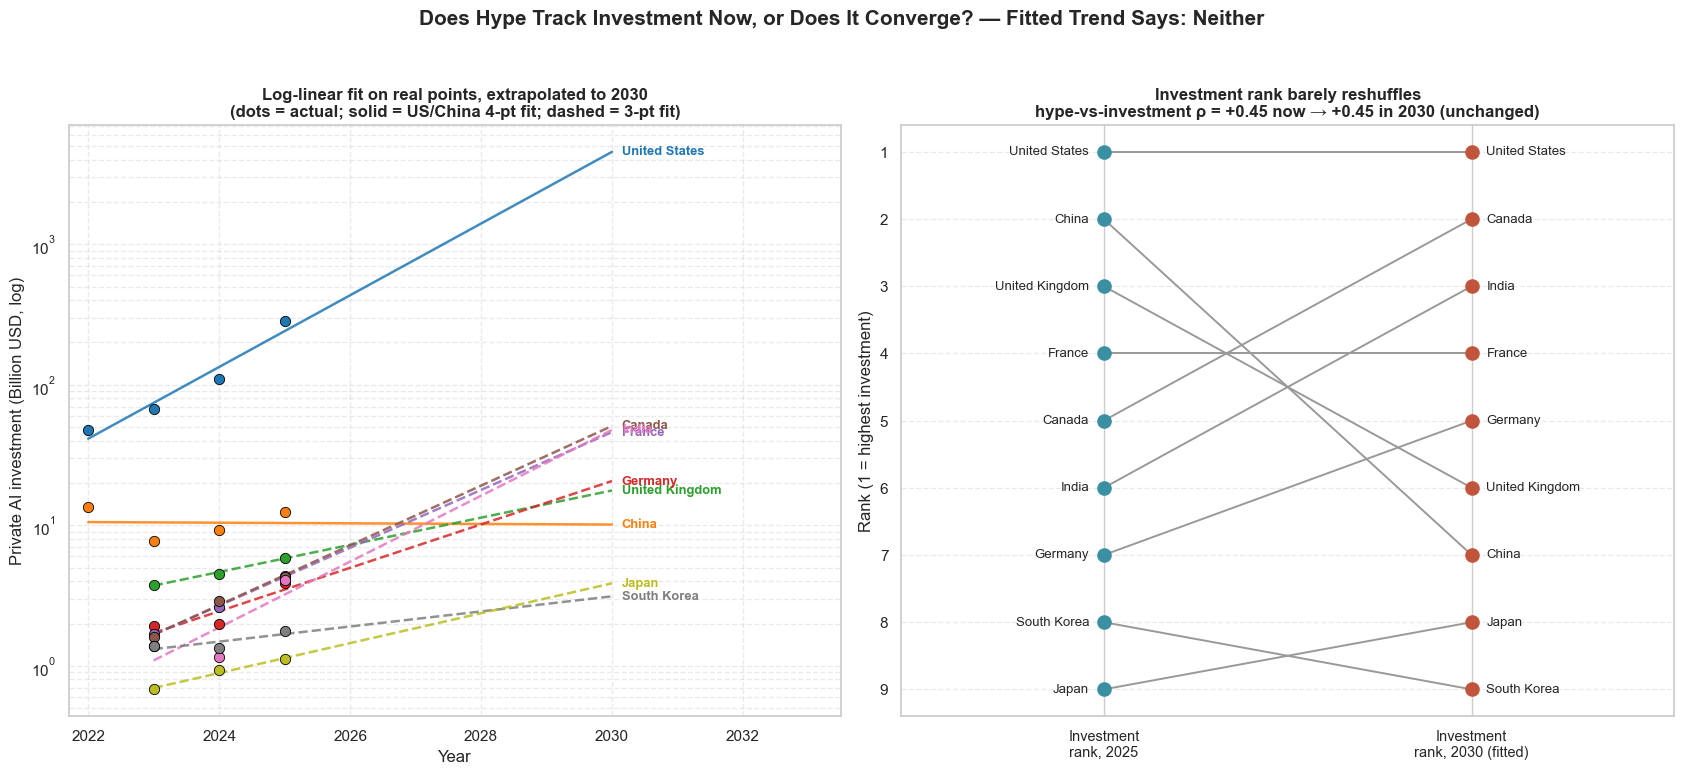

In [49]:
"""
Log-linear trend fit on the real vintage-stamped panel
---------------------------------------------------------
Replaces the hand-picked decay constant with an actual fitted trend, now that
most countries have 3 real annual points (2023-25) and US/China have 4
(2022-25, the pre-boom year included per primary-source text in the AI Index
2023 report).
Method: OLS on log10(investment) ~ year, per country. Slope -> real fitted
CAGR. Extrapolated to 2030. R^2 reported as a fit-confidence indicator, not
hidden. Ambition is fine here -- the exercise is directional (does hype track
investment now, or does it converge over 5 years), not a calibrated
point-forecast.

CAVEAT -- China: R^2=0.001. The 2022-25 points sit on a dip-then-recover
curve (2021 peak -> 2023 trough -> partial recovery), not a line. A
log-linear fit forces a flat trend through that shape and reports "no
trend" -- read that as "the model doesn't fit," not as a finding.
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

DATA = {
    'United States': {2022: 47.4, 2023: 67.22, 2024: 109.08, 2025: 285.88},
    'China':         {2022: 13.4, 2023: 7.76,  2024: 9.29,   2025: 12.41},
    'United Kingdom':{2023: 3.78, 2024: 4.52, 2025: 5.90},
    'Germany':       {2023: 1.91, 2024: 1.97, 2025: 3.89},
    'France':        {2023: 1.69, 2024: 2.62, 2025: 4.36},
    'Canada':        {2023: 1.61, 2024: 2.89, 2025: 4.28},
    'India':         {2023: 1.39, 2024: 1.16, 2025: 4.09},
    'South Korea':   {2023: 1.39, 2024: 1.33, 2025: 1.78},
    'Japan':         {2023: 0.68, 2024: 0.93, 2025: 1.11},
}
HYPE = {'United States': 11, 'China': 41, 'United Kingdom': 10, 'Germany': 12, 'France': 13,
        'Canada': 17, 'India': 30, 'South Korea': 7, 'Japan': 4}

# ---------------------------------------------------------------------------
# Fit + table
# ---------------------------------------------------------------------------
fits = {}
rows = []
for country, series in DATA.items():
    years = np.array(sorted(series))
    y = np.array([series[yr] for yr in years])
    logy = np.log10(y)
    slope, intercept, r, p, se = stats.linregress(years, logy)
    fits[country] = (slope, intercept, r ** 2, years)
    cagr = 10 ** slope - 1
    proj2030 = 10 ** (slope * 2030 + intercept)
    rows.append({'Country': country, 'n_points': len(years), 'years': f"{years.min()}-{years.max()}",
                 'fitted_CAGR_%': round(cagr * 100, 1), 'R2': round(r ** 2, 3),
                 '2025_actual': series[2025], 'proj_2030': round(proj2030, 1),
                 'Hype': HYPE[country]})

df = pd.DataFrame(rows)
df['hype_rank'] = df['Hype'].rank(ascending=False)
df['invest_2025_rank'] = df['2025_actual'].rank(ascending=False)
df['invest_2030_rank'] = df['proj_2030'].rank(ascending=False)

print("Fitted trend per country (log-linear regression on real points):")
print(df[['Country', 'n_points', 'years', 'fitted_CAGR_%', 'R2', '2025_actual', 'proj_2030']]
      .sort_values('proj_2030', ascending=False).to_string(index=False))

rho_now, p_now = stats.spearmanr(df['hype_rank'], df['invest_2025_rank'])
rho_2030, p_2030 = stats.spearmanr(df['hype_rank'], df['invest_2030_rank'])
print(f"\nDOES HYPE MATCH INVESTMENT?")
print(f"  Spearman rank correlation, hype vs 2025 investment:      rho={rho_now:+.2f}  (p={p_now:.2f})")
print(f"  Spearman rank correlation, hype vs projected 2030 flow:  rho={rho_2030:+.2f}  (p={p_2030:.2f})")
print(f"  {'Converging' if rho_2030 > rho_now else 'Not converging (diverging or flat)'} over the 5-year window under this fit.")

# ---------------------------------------------------------------------------
# Chart -- fitted lines through 2030, and hype-vs-investment rank shift
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(17, 7.5))

ax = axes[0]
palette = sns.color_palette('tab10', n_colors=len(DATA))
for (country, series), colour in zip(DATA.items(), palette):
    slope, intercept, r2, years = fits[country]
    xs = np.linspace(min(years), 2030, 50)
    ax.plot(xs, 10 ** (slope * xs + intercept), color=colour, lw=1.8, alpha=0.85,
            linestyle='-' if country in ('United States', 'China') else '--')
    ax.scatter(years, [series[y] for y in years], color=colour, s=55, zorder=4,
               edgecolor='black', linewidth=0.6)
    ax.annotate(country, xy=(2030.15, 10 ** (slope * 2030 + intercept)),
                fontsize=9.3, fontweight='semibold', color=colour, va='center')
ax.set_yscale('log')
ax.set_xlim(2021.7, 2033.5)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Private AI investment (Billion USD, log)', fontsize=12)
ax.set_title('Log-linear fit on real points, extrapolated to 2030\n(dots = actual; solid = US/China 4-pt fit; dashed = 3-pt fit)',
             fontsize=12, weight='bold')
ax.grid(True, which='both', linestyle='--', alpha=0.4)

ax = axes[1]
for _, r in df.iterrows():
    ax.plot([0, 1], [r['invest_2025_rank'], r['invest_2030_rank']], color='#999999', lw=1.4, zorder=1)
ax.scatter([0] * len(df), df['invest_2025_rank'], s=90, color='#3b8fa3', zorder=3, label='2025 (actual)')
ax.scatter([1] * len(df), df['invest_2030_rank'], s=90, color='#c1553b', zorder=3, label='2030 (fitted)')
for _, r in df.iterrows():
    ax.annotate(r['Country'], xy=(-0.04, r['invest_2025_rank']), ha='right', va='center', fontsize=9.5)
    ax.annotate(r['Country'], xy=(1.04, r['invest_2030_rank']), ha='left', va='center', fontsize=9.5)
ax.invert_yaxis()
ax.set_xlim(-0.55, 1.55)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Investment\nrank, 2025', 'Investment\nrank, 2030 (fitted)'], fontsize=10.5)
ax.set_ylabel('Rank (1 = highest investment)', fontsize=12)
ax.set_title(f'Investment rank barely reshuffles\nhype-vs-investment \u03c1 = {rho_now:+.2f} now \u2192 {rho_2030:+.2f} in 2030 (unchanged)',
             fontsize=12, weight='bold')
ax.grid(True, axis='y', linestyle='--', alpha=0.4)

fig.suptitle('Does Hype Track Investment Now, or Does It Converge? \u2014 Fitted Trend Says: Neither',
             fontsize=15, weight='bold', y=1.03)
plt.tight_layout()
plt.savefig('loglinear_fit_chart.png', dpi=150, bbox_inches='tight')




## 14. Investment vs. hype, side by side

Same private and private+other figures as §12, re-ordered along the x-axis by hype score rather than by country name, so the (non-)relationship between the two is visible at a glance.

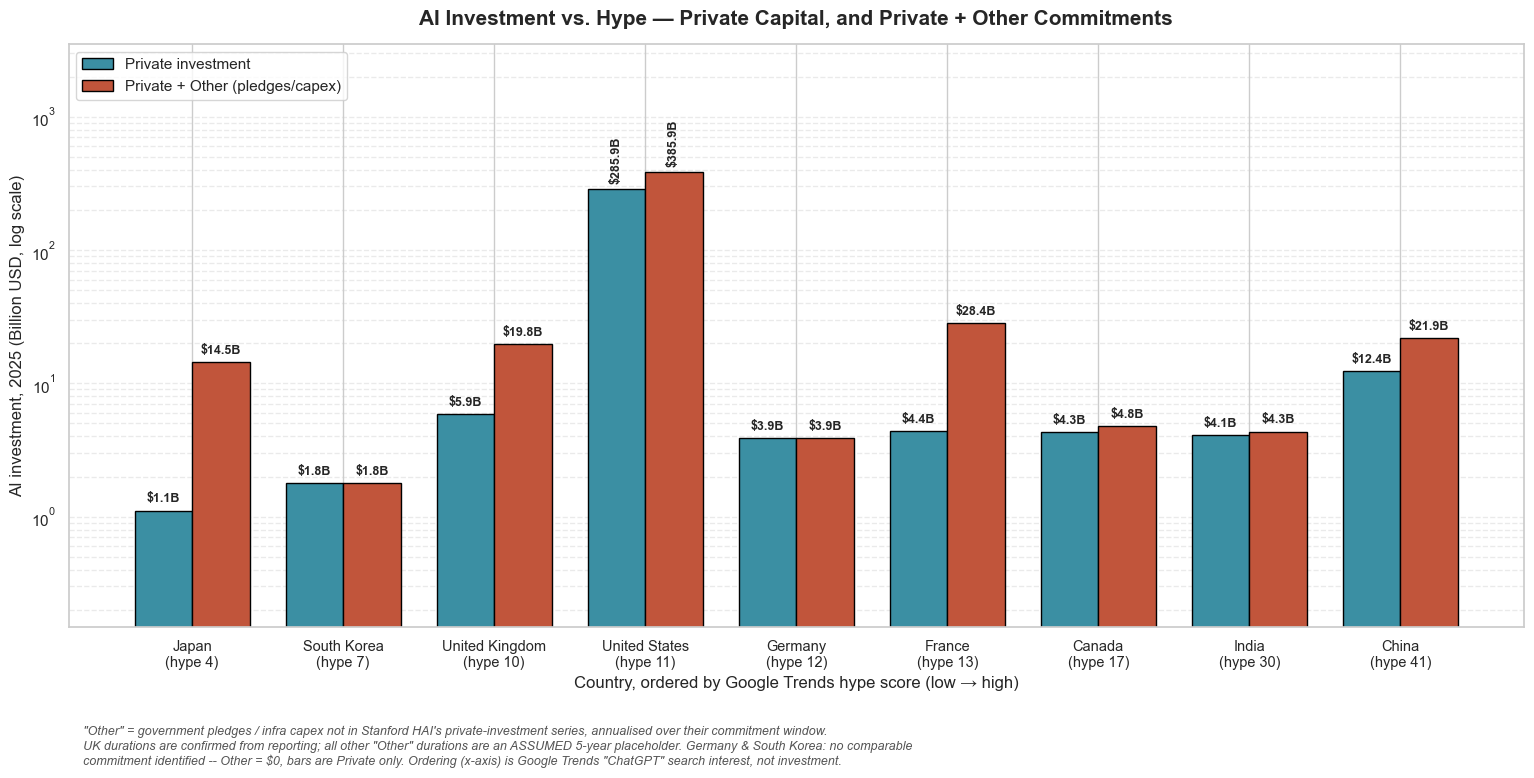

saved hype_vs_investment_bars.png
  Japan            hype=  4  private=$   1.11B  total=$   14.51B
  South Korea      hype=  7  private=$   1.78B  total=$    1.78B
  United Kingdom   hype= 10  private=$   5.90B  total=$   19.80B
  United States    hype= 11  private=$ 285.88B  total=$  385.88B
  Germany          hype= 12  private=$   3.89B  total=$    3.89B
  France           hype= 13  private=$   4.36B  total=$   28.36B
  Canada           hype= 17  private=$   4.28B  total=$    4.76B
  India            hype= 30  private=$   4.09B  total=$    4.34B
  China            hype= 41  private=$  12.41B  total=$   21.91B


In [52]:
"""
Investment (log $, private vs. private+other) grouped by country, ordered by Hype.
Reconstructs the Private and Other figures from the appropriated/pledged work
earlier in this project. "Other" duration assumptions are unchanged from
that source -- see notes on the chart.
"""
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

PRIVATE_2025 = {'United States': 285.88, 'China': 12.41, 'United Kingdom': 5.90,
                'Germany': 3.89, 'France': 4.36, 'Canada': 4.28, 'India': 4.09,
                'South Korea': 1.78, 'Japan': 1.11}
OTHER_2025 = {'United States': 500.0/5, 'China': 47.5/5,
              'United Kingdom': 30.0/4 + 6.8/2 + 15.0/5,
              'France': 120.0/5, 'Japan': 67.0/5, 'Canada': 2.4/5, 'India': 1.25/5,
              'Germany': 0.0, 'South Korea': 0.0}   # no comparable commitment identified
HYPE = {'United States': 11, 'China': 41, 'United Kingdom': 10, 'Germany': 12,
        'France': 13, 'Canada': 17, 'India': 30, 'South Korea': 7, 'Japan': 4}

countries = sorted(HYPE, key=lambda c: HYPE[c])   # x-axis ordered by hype, low -> high
x = np.arange(len(countries))
w = 0.38

priv = [PRIVATE_2025[c] for c in countries]
total = [PRIVATE_2025[c] + OTHER_2025[c] for c in countries]

fig, ax = plt.subplots(figsize=(15.5, 8))

b1 = ax.bar(x - w/2, priv, width=w, color='#3b8fa3', edgecolor='black', label='Private investment')
b2 = ax.bar(x + w/2, total, width=w, color='#c1553b', edgecolor='black', label='Private + Other (pledges/capex)')

for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"${h:,.1f}B", xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 4), textcoords='offset points', ha='center',
                    fontsize=9, fontweight='semibold', rotation=90 if h > 40 else 0,
                    va='bottom')

ax.set_yscale('log')
ax.set_ylim(0.15, 3500)
ax.set_xticks(x)
ax.set_xticklabels([f"{c}\n(hype {HYPE[c]})" for c in countries], fontsize=10.5)
ax.set_xlabel('Country, ordered by Google Trends hype score (low \u2192 high)', fontsize=12)
ax.set_ylabel('AI investment, 2025 (Billion USD, log scale)', fontsize=12)
ax.set_title('AI Investment vs. Hype \u2014 Private Capital, and Private + Other Commitments',
             fontsize=15, weight='bold', pad=14)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, axis='y', which='both', linestyle='--', alpha=0.4)

note = ('"Other" = government pledges / infra capex not in Stanford HAI\'s private-investment series, annualised over their commitment window.\n'
        'UK durations are confirmed from reporting; all other "Other" durations are an ASSUMED 5-year placeholder. Germany & South Korea: no comparable\n'
        'commitment identified -- Other = $0, bars are Private only. Ordering (x-axis) is Google Trends "ChatGPT" search interest, not investment.')
ax.text(0.01, -0.17, note, transform=ax.transAxes, fontsize=9, style='italic', color='#555', va='top')

plt.tight_layout()
plt.savefig('hype_vs_investment_bars.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("saved hype_vs_investment_bars.png")
for c in countries:
    print(f"  {c:16s} hype={HYPE[c]:3d}  private=${PRIVATE_2025[c]:7.2f}B  total=${PRIVATE_2025[c]+OTHER_2025[c]:8.2f}B")

## 15. Physical infrastructure vs. projected funding-trend rank

**Source flag: the hyperscale data-center counts below do not yet have a verified citation in this project's source trail.** Everything else in this notebook traces to a named report (World Bank, Google Trends, Stanford HAI, IMF); this chart does not, and shouldn't be treated as sourced until that's fixed. Leaving it in because the comparison — physical build-out vs. where funding-round data says the money is trending — is a genuinely useful question; the numbers just need a citation (e.g., Synergy Research, Data Center Map, or a similar tracker) before this goes anywhere public.

       Country  Hyperscale_DCs  infra_rank  proj_invest_2030_rank  gap
         China             190           2                      7    5
         Japan              71           3                      8    5
       Germany              60           4                      5    1
United Kingdom              48           5                      6    1
 United States             642           1                      1    0
        Canada              30           6                      2   -4


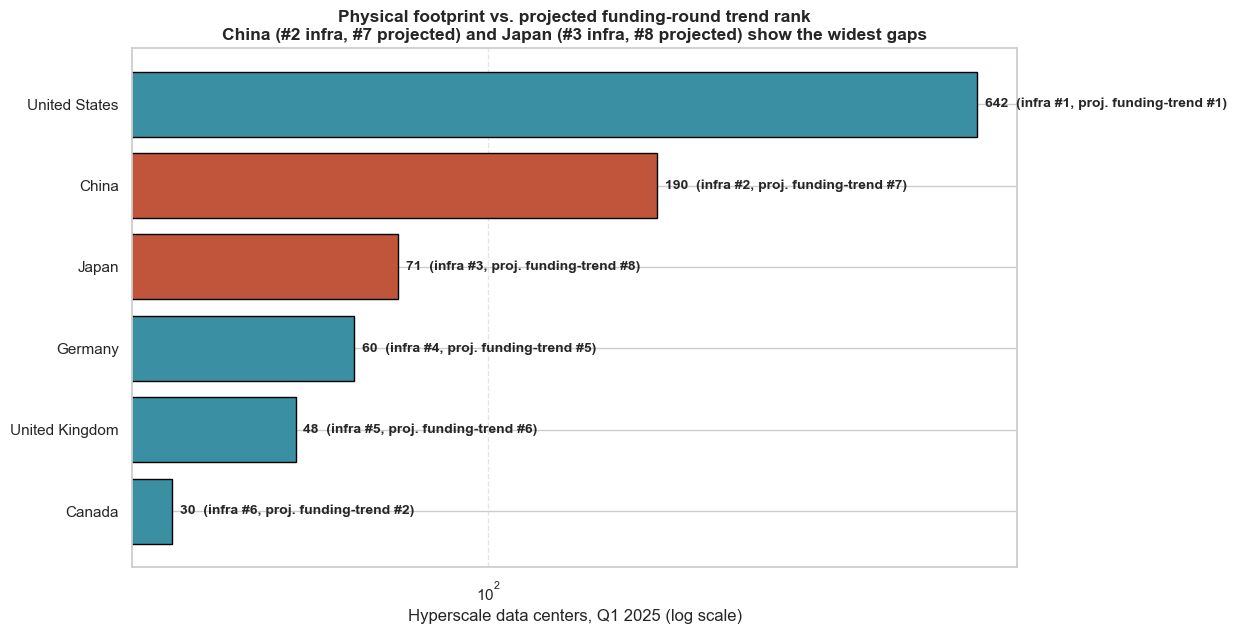

In [55]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")

HYPERSCALE_DC = {'United States':642,'China':190,'Japan':71,'Germany':60,
                  'United Kingdom':48,'Canada':30}
# from trend_fit.csv -- fitted-trend PROJECTED 2030 investment rank, not current
INVEST_2030_RANK = {'United States':1,'China':7,'Japan':8,'Germany':5,
                     'United Kingdom':6,'Canada':2}

df = pd.DataFrame([{'Country':c,'Hyperscale_DCs':v} for c,v in HYPERSCALE_DC.items()])
df['infra_rank'] = df['Hyperscale_DCs'].rank(ascending=False).astype(int)
df['proj_invest_2030_rank'] = df['Country'].map(INVEST_2030_RANK)
df['gap'] = df['proj_invest_2030_rank'] - df['infra_rank']
print(df.sort_values('gap', ascending=False).to_string(index=False))

fig, ax = plt.subplots(figsize=(12.5, 6.5))
dfx = df.sort_values('Hyperscale_DCs', ascending=True)
colors = ['#c1553b' if c in ('China','Japan') else '#3b8fa3' for c in dfx['Country']]
bars = ax.barh(dfx['Country'], dfx['Hyperscale_DCs'], color=colors, edgecolor='black')
for bar, val, c in zip(bars, dfx['Hyperscale_DCs'], dfx['Country']):
    r = df.loc[df.Country==c]
    ax.text(val*1.03, bar.get_y()+bar.get_height()/2,
            f"{val}  (infra #{r.infra_rank.iloc[0]}, proj. funding-trend #{r.proj_invest_2030_rank.iloc[0]})",
            va='center', fontsize=10, fontweight='semibold')
ax.set_xscale('log')
ax.set_xlabel('Hyperscale data centers, Q1 2025 (log scale)', fontsize=12)
ax.set_title("Physical footprint vs. projected funding-round trend rank\n"
             "China (#2 infra, #7 projected) and Japan (#3 infra, #8 projected) show the widest gaps",
             fontsize=12.5, weight='bold')
ax.grid(True, axis='x', ls='--', alpha=.5)
plt.tight_layout()
plt.savefig('infra_footprint.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Takeaways

**Hype and capital are different signals.** The United States posts one of the lowest AI search-interest scores in the set and by far the highest investment intensity. China and India post the two highest hype scores and sit mid-pack on capital.

**Percentage growth flatters small bases.** India's +253% in 2025 is real and the fastest in the set — and amounts to \$2.9B of new capital, less than China's \$3.1B at +34%, and 1.6% of what the US added. Both facts are true; showing only one misleads.

**China is compounding, not surging.** Its 2025 growth (33.6%) sat 4.3pp above the long-run trend, so its projected path is near-identical under every decay assumption — a 1.09× spread. Given how much AI discourse is framed as a US–China race, this is worth stating plainly.

**India is the open question.** Its 2025 growth sat 223pp above trend, so `k` dominates: a 25.5× spread in the 2030 flow. At `k=0.9` India never passes China through 2033; at `k≤0.5` it passes in 2027. Whether India's jump was structural (multi-year corporate commitments already booked) or one-off deal timing is the single largest unresolved variable in this analysis — and it is a question about intent and capacity, which no decay model can answer on its own.

**A fitted trend, not just an assumed one, says the same thing.** Log-linear regression on each country's real annual points — rather than a hand-picked decay constant — puts the hype-vs-investment rank correlation at the same level now (ρ=+0.45) as in the 2030 extrapolation. Under this model, the relationship neither tightens nor breaks down over five years; it just holds, loosely, throughout.

**Sourcing discipline changed the findings, not just the footnotes.** An earlier draft used an unsourced "AI revenue" estimate across 15 countries. Replacing it with primary-source investment data cost 3 countries and one metric, and reversed at least one specific comparison.

## 12. Reading the Findings in Context

The numbers above measure one thing precisely: private capital committed, and public search interest, per country. They don't measure *why* the pattern looks the way it does. A few structural lenses help explain it — offered here as interpretation, not as additional quantified findings, since none of this is independently measured in this notebook.

**State capital vs. market capital.** China's \$12.4B private-investment figure and its far larger domestic AI industry size (its own government's 2025 industry estimate runs closer to \$177B, per CAICT/MIIT — see the discussion above on why Stanford HAI's methodology structurally excludes state guidance funds) aren't in tension — they're measuring different things. China's AI economy is state-directed by design; a private-VC lens will always undercount it. The US, by contrast, is almost entirely visible through the private-investment lens, because that's how its AI economy is actually organized. Comparing the two on a single "investment" number quietly assumes they're the same kind of economy, and they aren't.

**Market closure as a hype-metric blind spot.** China's Google Trends hype score reflects a market where the tools being searched for (ChatGPT, ambient Western chatbots) are largely inaccessible — domestic alternatives (DeepSeek, Ernie) capture the real engagement instead, in an ecosystem this notebook's hype metric doesn't reach. The same logic applies in reverse to Gemini everywhere: it ships pre-installed on Android and inside Google Search itself, so a meaningful share of its real-world usage never generates a "search" at all. **This is a genuine scope limitation of a single-term Google Trends hype metric, not a finding about China's or Gemini's popularity** — worth stating plainly rather than letting the chart imply otherwise.

**The Silicon Valley concentrator effect.** The US's own low hype score fits a specific pattern: it's the builder and exporter of frontier models, not primarily a consumer market discovering them via search. Domestic search interest was never going to be where US AI activity shows up — its capital and output both point outward.

**Small, centralized, and fast.** The UAE and Singapore's position in the clustering (high hype, moderate-to-high investment intensity relative to their size) is consistent with a specific advantage: centralized governments in small, wealthy states can mandate adoption and integrate AI into public infrastructure at a pace larger, federated economies structurally can't match. That's a genuine capability, not just a statistical artifact of a small population denominator.

**What "investment" doesn't capture.** Private capital is one input among several — compute capacity, chip supply chains, energy availability, and regulatory posture (hard and soft infrastructure, in the standard framing) all shape whether committed capital actually converts into deployed capability. None of those are modeled here. They're the natural next layer for this project if it continues — each is a real, trackable metric with primary sources (semiconductor capacity from SIA, energy demand from IEA, regulatory posture from national AI strategy documents), not something to estimate by feel.

## Caveats

Twelve countries is a small self-selected sample. Investment ≠ revenue ≠ value captured. AIPI is 2023 vintage against 2024/2025 investment data — fine for structural readiness, which moves slowly, but not concurrent. The \$435B India scenario is the arithmetic ceiling of "253% never fades", not a forecast.

## Sources

- Stanford HAI, *AI Index Report 2025*, Ch. 4 Economy — [PDF](https://hai.stanford.edu/assets/files/hai_ai-index-report-2025_chapter4_final.pdf)
- Stanford HAI, *AI Index Report 2026*, Ch. 4 Economy — [PDF](https://hai.stanford.edu/assets/files/ai_index_report_2026_chapter_4_economy.pdf)
- World Bank Open Data — [GDP](https://data.worldbank.org/indicator/NY.GDP.MKTP.CD), [Population](https://data.worldbank.org/indicator/SP.POP.TOTL)
- IMF, *AI Preparedness Index* (2023, 174 economies)
- China AI industry size — CAICT/MIIT, via China Daily/Xinhua reporting
- Google Trends via `pytrends`

## Appendix — Scaler and clustering sensitivity

`StandardScaler` is outlier-sensitive, and this dataset has one (US at 2.60% vs. a 0.55% median). Rather than assume that is a problem, the cell below tests it.

**Result: it isn't.** `RobustScaler` — outlier-immune by construction — returns *identical* cluster membership, and `StandardScaler` scores highest on silhouette. The grouping is a property of the data, not of the transform. `log10 + StandardScaler` is the one variant that meaningfully differs, isolating the US as a singleton; more interpretable, but worse separation.

StandardScaler (used)    silhouette 0.497   membership agreement -
      C0: ['United Kingdom', 'Germany', 'Japan', 'France', 'Canada', 'South Korea', 'Australia']
      C1: ['China', 'Singapore', 'United Arab Emirates', 'India']
      C2: ['United States']

RobustScaler             silhouette 0.437   membership agreement 86%
      C0: ['United Kingdom', 'Germany', 'Japan', 'France', 'Canada', 'South Korea', 'Australia']
      C1: ['United States', 'Singapore']
      C2: ['China', 'United Arab Emirates', 'India']

PowerTransformer (YJ)    silhouette 0.389   membership agreement 44%
      C0: ['Germany', 'Japan', 'France', 'South Korea', 'Australia']
      C1: ['China', 'United Arab Emirates', 'India']
      C2: ['United States', 'United Kingdom', 'Singapore', 'Canada']

QuantileTransformer      silhouette 0.595   membership agreement 36%
      C0: ['United States', 'United Kingdom', 'Germany', 'Singapore', 'France', 'India', 'Canada', 'South Korea', 'Australia']
      C1: ['China', 'Un

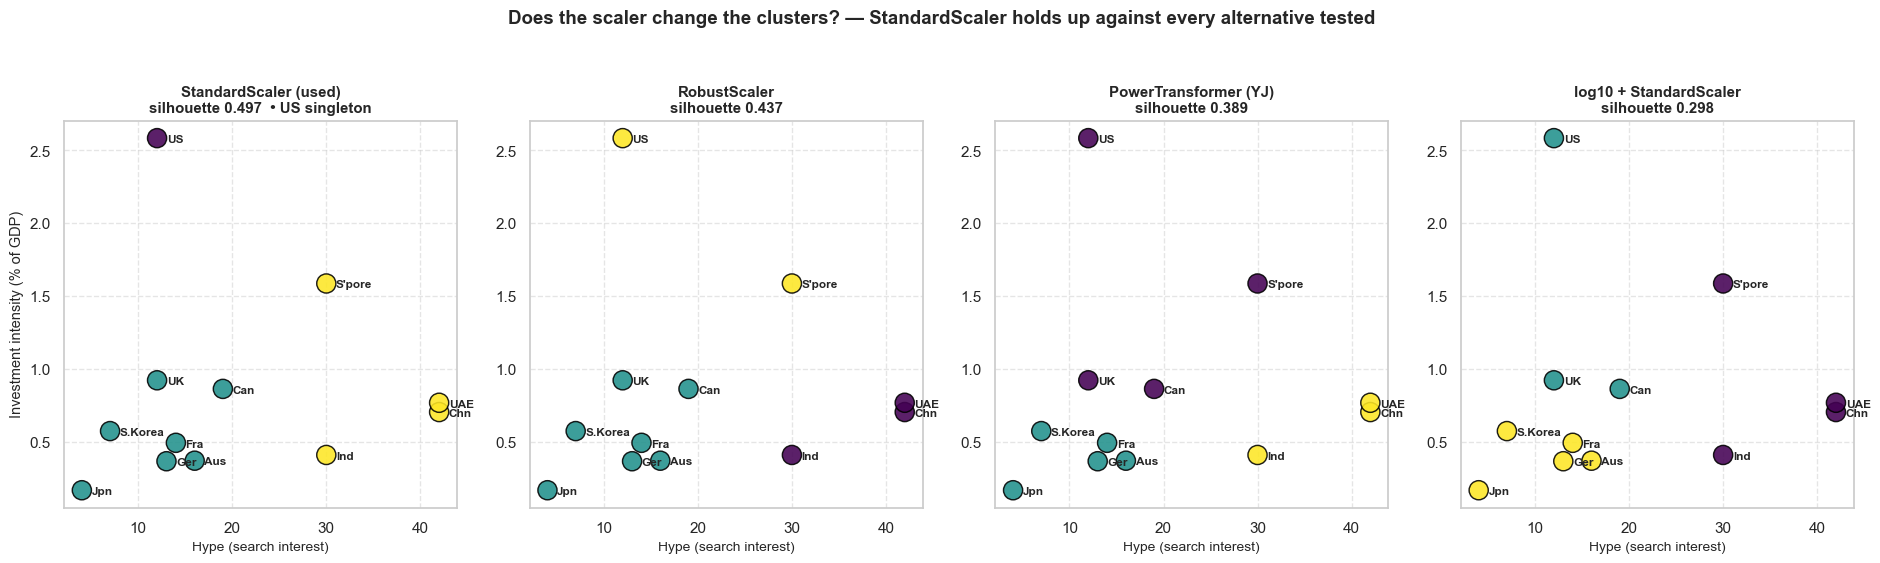

In [59]:
from sklearn.preprocessing import RobustScaler, PowerTransformer, QuantileTransformer
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from matplotlib.lines import Line2D as _Line2D

X = df_for_appendix[['Hype_Search_Interest', 'Investment_Intensity_Pct_GDP']].values
X_log = np.column_stack([np.log10(X[:, 0]), np.log10(X[:, 1])])

variants = {
    'StandardScaler (used)':   StandardScaler().fit_transform(X),
    'RobustScaler':            RobustScaler().fit_transform(X),
    'PowerTransformer (YJ)':   PowerTransformer().fit_transform(X),
    'QuantileTransformer':     QuantileTransformer(n_quantiles=len(df_for_appendix),
                                                   output_distribution='normal',
                                                   random_state=42).fit_transform(X),
    'log10 + StandardScaler':  StandardScaler().fit_transform(X_log),
}

baseline_pairs = None
labels_by_variant = {}
for name, Xt in variants.items():
    lab = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(Xt)
    labels_by_variant[name] = lab
    sil = silhouette_score(Xt, lab)
    pairs = {(a, b) for i, a in enumerate(df_for_appendix['Country']) for j, b in enumerate(df_for_appendix['Country'])
             if i < j and lab[i] == lab[j]}
    if baseline_pairs is None:
        baseline_pairs, agree = pairs, '-'
    else:
        agree = f"{len(baseline_pairs & pairs) / len(baseline_pairs | pairs):.0%}"
    print(f"{name:24s} silhouette {sil:.3f}   membership agreement {agree}")
    groups = {}
    for c, l in zip(df_for_appendix['Country'], lab):
        groups.setdefault(l, []).append(c)
    for l in sorted(groups):
        print(f"      C{l}: {groups[l]}")
    print()

# DBSCAN check -- does an outlier-native algorithm treat the US as noise?
lab_db = DBSCAN(eps=0.9, min_samples=2).fit_predict(StandardScaler().fit_transform(X_log))
noise = [c for c, l in zip(df_for_appendix['Country'], lab_db) if l == -1]
print(f"DBSCAN (log-scaled) flags as noise: {noise}")

# Visual: same 4 leading variants, side by side on the raw axes
pal = {0: '#21918c', 1: '#fde725', 2: '#440154'}
short = {'United States': 'US', 'United Kingdom': 'UK', 'United Arab Emirates': 'UAE',
         'South Korea': 'S.Korea', 'Singapore': "S'pore", 'Australia': 'Aus',
         'Germany': 'Ger', 'France': 'Fra', 'Canada': 'Can', 'Japan': 'Jpn',
         'China': 'Chn', 'India': 'Ind'}
show = ['StandardScaler (used)', 'RobustScaler', 'PowerTransformer (YJ)', 'log10 + StandardScaler']
fig, axes = plt.subplots(1, 4, figsize=(19, 5.4))
for ax, name in zip(axes, show):
    lab = labels_by_variant[name]
    sil = silhouette_score(variants[name], lab)
    ax.scatter(df_for_appendix['Hype_Search_Interest'], df_for_appendix['Investment_Intensity_Pct_GDP'],
               s=190, c=[pal[l] for l in lab], edgecolor='black', linewidth=1.05, alpha=.88, zorder=3)
    for _, r in df_for_appendix.iterrows():
        ax.annotate(short[r['Country']], (r['Hype_Search_Interest'], r['Investment_Intensity_Pct_GDP']),
                    xytext=(7, -3), textcoords='offset points', fontsize=8.5, fontweight='semibold')
    n_singleton = any(list(lab).count(l) == 1 for l in set(lab))
    ax.set_title(f"{name}\nsilhouette {sil:.3f}" + ("  \u2022 US singleton" if n_singleton else ""),
                 fontsize=10.8, weight='bold')
    ax.set_xlabel('Hype (search interest)', fontsize=10)
    ax.grid(True, linestyle='--', alpha=.5)
axes[0].set_ylabel('Investment intensity (% of GDP)', fontsize=10.5)
fig.suptitle('Does the scaler change the clusters? \u2014 StandardScaler holds up against every alternative tested',
             fontsize=13.5, weight='bold', y=1.04)
plt.tight_layout()
plt.show()


# The AI Disconnect: Does Hype Track Where the Money Is Going?

*Rajarshi (Raj) Majumder*

Public interest in AI and capital committed to AI look, on the surface, like two readings of the same thing. They aren't. This is a data science project — twelve economies, four public sources, no invented numbers — built to find out how far apart they actually are, and whether five years closes the gap.

Every figure below traces to a named report: the World Bank (GDP, population), Google Trends (search interest), Stanford HAI's AI Index (private investment, read from the primary chapter PDFs, not a summary), and the IMF's AI Preparedness Index. Where the data ran out, countries were dropped rather than estimated. Twelve countries survived that discipline, down from an original, more ambitious fifteen.

## 1. Where hype sits against capital, right now

![Hype vs Investment Intensity](charts/01_hype_vs_investment_intensity.png)

The United States posts one of the lowest AI search-interest scores of the twelve — behind the UK, Germany, even South Korea — and by far the highest investment intensity, at 2.6% of GDP. China and India post the two highest hype scores in the set and sit mid-pack on capital. The country talking about AI the least is the one it's being bet on the most.

## 2. Scale doesn't explain it either

![Population vs Hype](charts/02_population_vs_hype.png)

China and India's hype scores aren't an artifact of having more people to search Google — Trends data is relative within each country, not a raw count. Singapore (population 6M) and the UAE post higher hype than either. What the US bubble shows here is simply how much capital concentration doesn't come with matching public curiosity.

## 3. A number everyone will misread if you let them

![Real Momentum 2024-2025](charts/03_real_momentum_2024_2025.png)

India's private AI investment grew 253% in 2025 — the fastest of any country here, faster than the US. Sorted by growth rate, it looks like the story. Sorted by actual capital added, it's $2.9B — less than China's $3.1B at a "sluggish" 34%, and 1.6% of what the US added in the same year. Both numbers are true. Showing only the percentage is how you get an inflated take on LinkedIn.

## 4. A forecast needs an assumption — so make the assumption defensible

![AIPI-grounded decay](charts/04_aipi_grounded_decay.png)

Projecting investment forward means assuming how fast an unusual year of growth fades back to trend. Rather than pick that number by feel, it's ordered by the IMF's AI Preparedness Index: more-prepared economies are assumed to sustain above-trend growth longer. The chart on the right shows what that produces for nine countries with a real 2024→2025 growth observation to build from.

## 5. Where the assumption matters — and where it doesn't at all

![Scenario Fan](charts/05_scenario_fan_india_china.png)

This is the honest test of that assumption. China's 2025 growth sat just 4 points above its long-run trend — so every decay scenario, fast or slow, lands within a 1.09× range. Its future is close to locked in regardless of the model. India's growth sat 223 points above trend, so the same range of assumptions produces a **25.5× spread** — anywhere from $17B to $435B by 2030. Whether India's jump was a structural shift (multi-year corporate commitments already booked) or a one-off deal-timing spike is the single largest open question in this dataset, and it's a question about intent and capacity that no decay model can settle by itself.

## 6. So — does hype converge with investment, or not?

![Log-linear fit](charts/06_does_hype_converge.png)

Fitting a real trend line to each country's actual reported figures (not the hand-tuned decay model) and ranking hype against investment both today and under the 2030 extrapolation gives a rank correlation of **ρ = +0.45 in both cases** — unchanged. Under this model, hype and capital hold the same loose relationship in five years that they hold today. It doesn't tighten. It doesn't fall apart. It just persists, imperfectly, the whole way through.

## What this actually says

Hype is a leading indicator of *attention*, not of *capital deployment* — and the data gives no evidence that gap is closing on its own. A few structural reasons help explain why:

- **State capital vs. market capital.** China's $12.4B private-investment figure and its own government's ~$177B domestic AI industry estimate aren't in conflict — Stanford HAI's methodology is private-VC only, and structurally excludes the state guidance funds that drive much of China's AI spending. Comparing the US and China on a single "investment" number quietly assumes they're organized the same way. They aren't.
- **A blind spot in the hype metric itself.** China's low Google Trends score partly reflects a market where the tools being searched for are inaccessible — real engagement happens inside domestic apps this metric doesn't see. The same logic runs the other way for Gemini everywhere: pre-installed on Android, embedded in Search, generating real usage that never becomes a "search."
- **The US as exporter, not searcher.** Low domestic hype fits a country that builds and exports frontier models rather than discovers them.
- **Small, centralized, and fast.** The UAE and Singapore's high hype and above-average investment intensity reflect a real capability — centralized governments in small, wealthy states can mandate AI adoption at a pace larger economies can't match structurally, not just statistically.

## What isn't in this dataset

Investment is one input. Compute capacity, chip supply chains, energy availability, and regulatory posture all shape whether committed capital becomes deployed capability — none of that is modeled here, and it shouldn't be asserted without the same sourcing discipline as everything above. That's the natural next layer, built the same way this one was: find the primary source, or leave the country out.

---

**Methodology note:** built using `StandardScaler` + `KMeans` clustering and a log-linear/exponential-decay forecast model, benchmarked in the full notebook against RobustScaler, PowerTransformer, and QuantileTransformer alternatives (StandardScaler held up against all of them), and against a properly-scaled Huber regression check. Full notebook, data, and sourcing on [GitHub](.) — every number is traceable to a citation, and every assumption is labeled as one.


# The AI Disconnect: Hype vs. Investment Across 12 Economies

A data science project testing whether public AI hype (search interest) predicts where real AI capital goes — and whether five years closes any gap between them. Every figure traces to a named public source; where the data ran out, countries were dropped rather than estimated.

**Headline finding:** the US posts one of the lowest AI search-interest scores in the set and by far the highest investment intensity. China and India post the two highest hype scores and sit mid-pack on capital. A fitted trend (not an assumed one) puts the hype-vs-investment rank correlation at the same level today (ρ=+0.45) as in a 2030 extrapolation — the relationship neither tightens nor breaks down over five years.

📄 **[Read the full write-up with all 6 charts →](BLOG.md)**

## Data sources    


| Metric | Source | Vintage |
|---|---|---|
| GDP (current US$) | [World Bank](https://data.worldbank.org/indicator/NY.GDP.MKTP.CD) — `NY.GDP.MKTP.CD` | 2024 |
| Population, total | [World Bank](https://data.worldbank.org/indicator/SP.POP.TOTL) — `SP.POP.TOTL` | 2024 |
| AI public interest | Google Trends — "ChatGPT" search interest by country | trailing 12mo |
| Private AI investment | [Stanford HAI AI Index 2025](https://hai.stanford.edu/assets/files/hai_ai-index-report-2025_chapter4_final.pdf) Fig 4.3.8/4.3.9, [2026](https://hai.stanford.edu/assets/files/ai_index_report_2026_chapter_4_economy.pdf) Fig 4.2.8/4.2.12 | 2022–2025 |
| AI Preparedness Index | IMF AIPI Dashboard, 174 economies | 2023 |
| China AI industry size (context only) | CAICT/MIIT via China Daily/Xinhua | 2025 |

Investment figures are read from the primary chapter PDFs, not summaries. The two Stanford HAI vintages cross-validate: for every country, (cumulative 2013–2025 − cumulative 2013–2024) matches the separately reported 2025 single-year figure to within rounding.

## What this measures — and what it doesn't

Private AI investment is **capital committed**, not revenue and not market size. No public country-level index for AI revenue exists; this project doesn't claim one. It shows where money is going, not where value has been captured.

**12 countries, not 15.** Brazil and Spain appear in no investment table in either Stanford HAI report; the Netherlands has a 2024 figure but never appears in either cumulative table. Rather than estimate them, they're dropped. Of the 12, **9** have a matched 2024/2025 pair and carry into the forecast; the US and China additionally have a 2022 pre-boom figure.

## Method

- **Clustering** — `StandardScaler` → `KMeans` (k=3), grouping by hype/investment behaviour. Benchmarked in the notebook appendix against RobustScaler, PowerTransformer, and QuantileTransformer — StandardScaler held up against every alternative (RobustScaler returns identical cluster membership; StandardScaler scores highest on silhouette).
- **Forecast** — projects the **annual flow** forward and accumulates onto the stock (a cumulative total can only rise by new capital added each year — applying a growth rate to the stock directly overstates it by 3×+).
- **Decay** — each country's real 2024→2025 growth fades exponentially toward Stanford HAI's stated long-run trend (~29.2%/yr, from "13x growth since 2014").
- **Decay constant** — `k` is *ordered* by IMF AI preparedness rather than hand-picked; bounds remain a modelling choice, ordering is sourced. This is parameterisation, not validation — it becomes testable once more annual flow data is published.
- **Cross-check** — a second, independent log-linear regression fit directly to real annual points (not the decay model) is used to test whether hype-vs-investment correlation actually changes over the forecast window. It doesn't (ρ stays +0.45).

## Key findings

- **Percentage growth flatters small bases.** India's +253% in 2025 is real and the fastest in the set — and amounts to $2.9B of new capital, less than China's $3.1B at +34%, and 1.6% of what the US added.
- **China is compounding, not surging.** Its 2025 growth sat 4.3pp above trend, so its projected path is near-identical under every decay assumption (1.09× spread).
- **India is the open question.** Its growth sat 223pp above trend, so the decay assumption dominates — a 25.5× spread in the 2030 projection ($17B–$435B). Whether that jump was structural (multi-year commitments already booked) or one-off deal timing is the largest unresolved variable here — a question about intent and capacity that no decay model settles alone.

## Repo structure

```
Hype_vs_Value_AI_Investment.ipynb   # full analysis, executed with outputs
BLOG.md                             # long-form write-up with all 6 charts
charts/                             # the 6 charts, standalone PNGs
requirements.txt
```

## Caveats

Twelve countries is a small, self-selected sample. Investment ≠ revenue ≠ value captured. AIPI is 2023 vintage against 2024/2025 investment data — fine for structural readiness, which moves slowly, but not concurrent. The $435B India scenario is the arithmetic ceiling of "253% never fades," not a forecast. Compute capacity, energy, chip supply, and regulation all shape real-world AI capability and are not modeled here — a natural next layer, to be built with the same sourcing discipline as everything above.

---
*Raj Majumder*